# Complete Analysis of NoteBook :

**Project :** Global Pollution Analysis with Apriori Association-Rule Mining
- **Data :** `Global_Pollution_Analysis.csv` (200 country-year records, 2000–2019)


## Pipeline covered in `main.ipynb`
1. **Step 1 — Data Import & Preprocessing**
2. **Step 2 — Exploratory Data Analysis (EDA)**
3. **Step 3 — Feature Engineering**
4. **Apriori association-rule mining** (frequent itemsets → `lift`-ranked rules)
5. **Interpretation & visualization** of the discovered rules




# **Step 1 - Data Import and Preprocessing**


**Review of Cell 1.** Imports the core libraries used throughout the project — NumPy and pandas (data handling), Seaborn and Matplotlib (visualization) — and disables warnings so the output stays clean.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

**Review of Cell 2.** Loads the dataset `Global_Pollution_Analysis.csv` into the DataFrame `df`. This is the single source of data for the whole analysis.

In [2]:
df = pd.read_csv('Global_Pollution_Analysis.csv')

**Review of Cell 3.** Displays the first 5 rows. **Result:** each row is one *country-year* record with 13 attributes (three pollution indices, industrial & plastic waste, energy recovery/consumption, CO₂, renewables, population, GDP). Values are large and on very different scales (e.g. pollution ~100 vs GDP ~35,000) → preprocessing is needed.

In [3]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


**Review of Cell 4.** Returns the dataset dimensions: **`(200, 13)`** → 200 observations and 13 columns.

In [4]:
df.shape

(200, 13)

**Review of Cell 5.** Prints column dtypes and memory usage. **Result:** all 200 rows are non-null; 11 columns are `float64`, `Year` is `int64`, `Country` is a string. The three pollution indices and waste/energy/GDP columns are continuous numerical features.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu



---

NO - NULL 

**Review of Cell 7.** Counts cells containing an *empty string* instead of a value. **Result:** every column shows **0** → there are no blank/placeholder entries either.

In [6]:
(df == "").sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

**Review of Cell 8.** Counts fully duplicated rows. **Result:** **0** duplicates → the dataset is clean and needs no de-duplication.

In [7]:
df.duplicated().sum()

np.int64(0)

**Review of Cell 9.** Creates `df_new`, a copy of `df`, so the original data stays untouched while categorical columns are encoded.

In [8]:
df_new = df.copy()

**Review of Cell 10.** Applies `StandardScaler` to the three pollution indices (`Air`, `Water`, `Soil`). **Purpose:** rescaling removes the arbitrary differences in magnitude so all numeric features are comparable on a mean-0, std-1 scale.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])

     

**Review of Cell 11.** Applies `LabelEncoder` to `Country` and `Year`, turning them into integer labels so the whole frame can be treated numerically. (Note: one shared `LabelEncoder` is re-fitted per column — this is fine for the 20 distinct year labels and unique country codes used here.)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new['Country'] = le.fit_transform(df['Country'])
df_new['Year'] = le.fit_transform(df['Year'])
     

In [11]:
df_new.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,92,4,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,11,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,41,10,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


**Review of Cell 13.** Sorts by `Year` to discover the time span. **Result:** years run from **2000 to 2019** → 20 distinct years, 10 country records per year on average.

In [12]:
df.sort_values(by='Year')['Year']

14     2000
10     2000
25     2000
39     2000
42     2000
       ... 
62     2019
169    2019
132    2019
131    2019
157    2019
Name: Year, Length: 200, dtype: int64

**Review of Cell 14.** Confirms the observation noted in the notebook: the dataset covers the period **2000–2019**.

---

So data is from year 2000 to 2019 

**Review of Cell 15.** The heading that opens **Step 2 – Exploratory Data Analysis (EDA)** in the original notebook.

---

Step 2 - Exploratory Data Analysis (EDA)


**Review of Cell 16.** Summary statistics of the encoded/standardized `df_new`. **Result highlights:** pollution indices have mean ≈ 0 and std ≈ 1 (post-scaling); • Industrial waste mean ≈ 52.9k tons (max ≈ 99.7k); • Energy recovered mean ≈ 260 GWh; • CO₂ mean ≈ 24.9 MT (range 1.9–49.7); • Renewable share mean ≈ 27.8%; • Plastic waste mean ≈ 24.5k tons; • GDP per capita mean ≈ $35.3k (range $1.3k–$69.1k).

In [13]:
df_new.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


**Review of Cell 17.** Re-prints data types on the original `df`: 11 `float64`, 1 `int64` (`Year`), 1 object/string (`Country`) — confirms the frame is entirely numeric after encoding.

In [14]:
df.dtypes

Country                                       str
Year                                        int64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
dtype: object

**Review of Cell 19.** Computes Pearson correlation of every feature with **`Energy_Recovered (in GWh)`**. **Result:** all correlations are weak — the strongest is `Industrial_Waste` (−0.16), followed by `Year` (+0.09); everything else is negligible. No single feature linearly drives energy recovery.

In [15]:
correlation = df_new.corr(numeric_only=True)["Energy_Recovered (in GWh)"]
correlation

Country                                  -0.044316
Year                                      0.088332
Air_Pollution_Index                       0.002997
Water_Pollution_Index                    -0.041828
Soil_Pollution_Index                      0.064076
Industrial_Waste (in tons)               -0.161309
Energy_Recovered (in GWh)                 1.000000
CO2_Emissions (in MT)                     0.024758
Renewable_Energy (%)                      0.043533
Plastic_Waste_Produced (in tons)         -0.072946
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Population (in millions)                 -0.075100
GDP_Per_Capita (in USD)                   0.004535
Name: Energy_Recovered (in GWh), dtype: float64

**Review of Cell 20.** Full correlation heatmap of the encoded `df_new`. **Result:** the map is almost uniformly pale → the variables are largely **independent** of each other (no strong multicollinearity).

<Axes: >

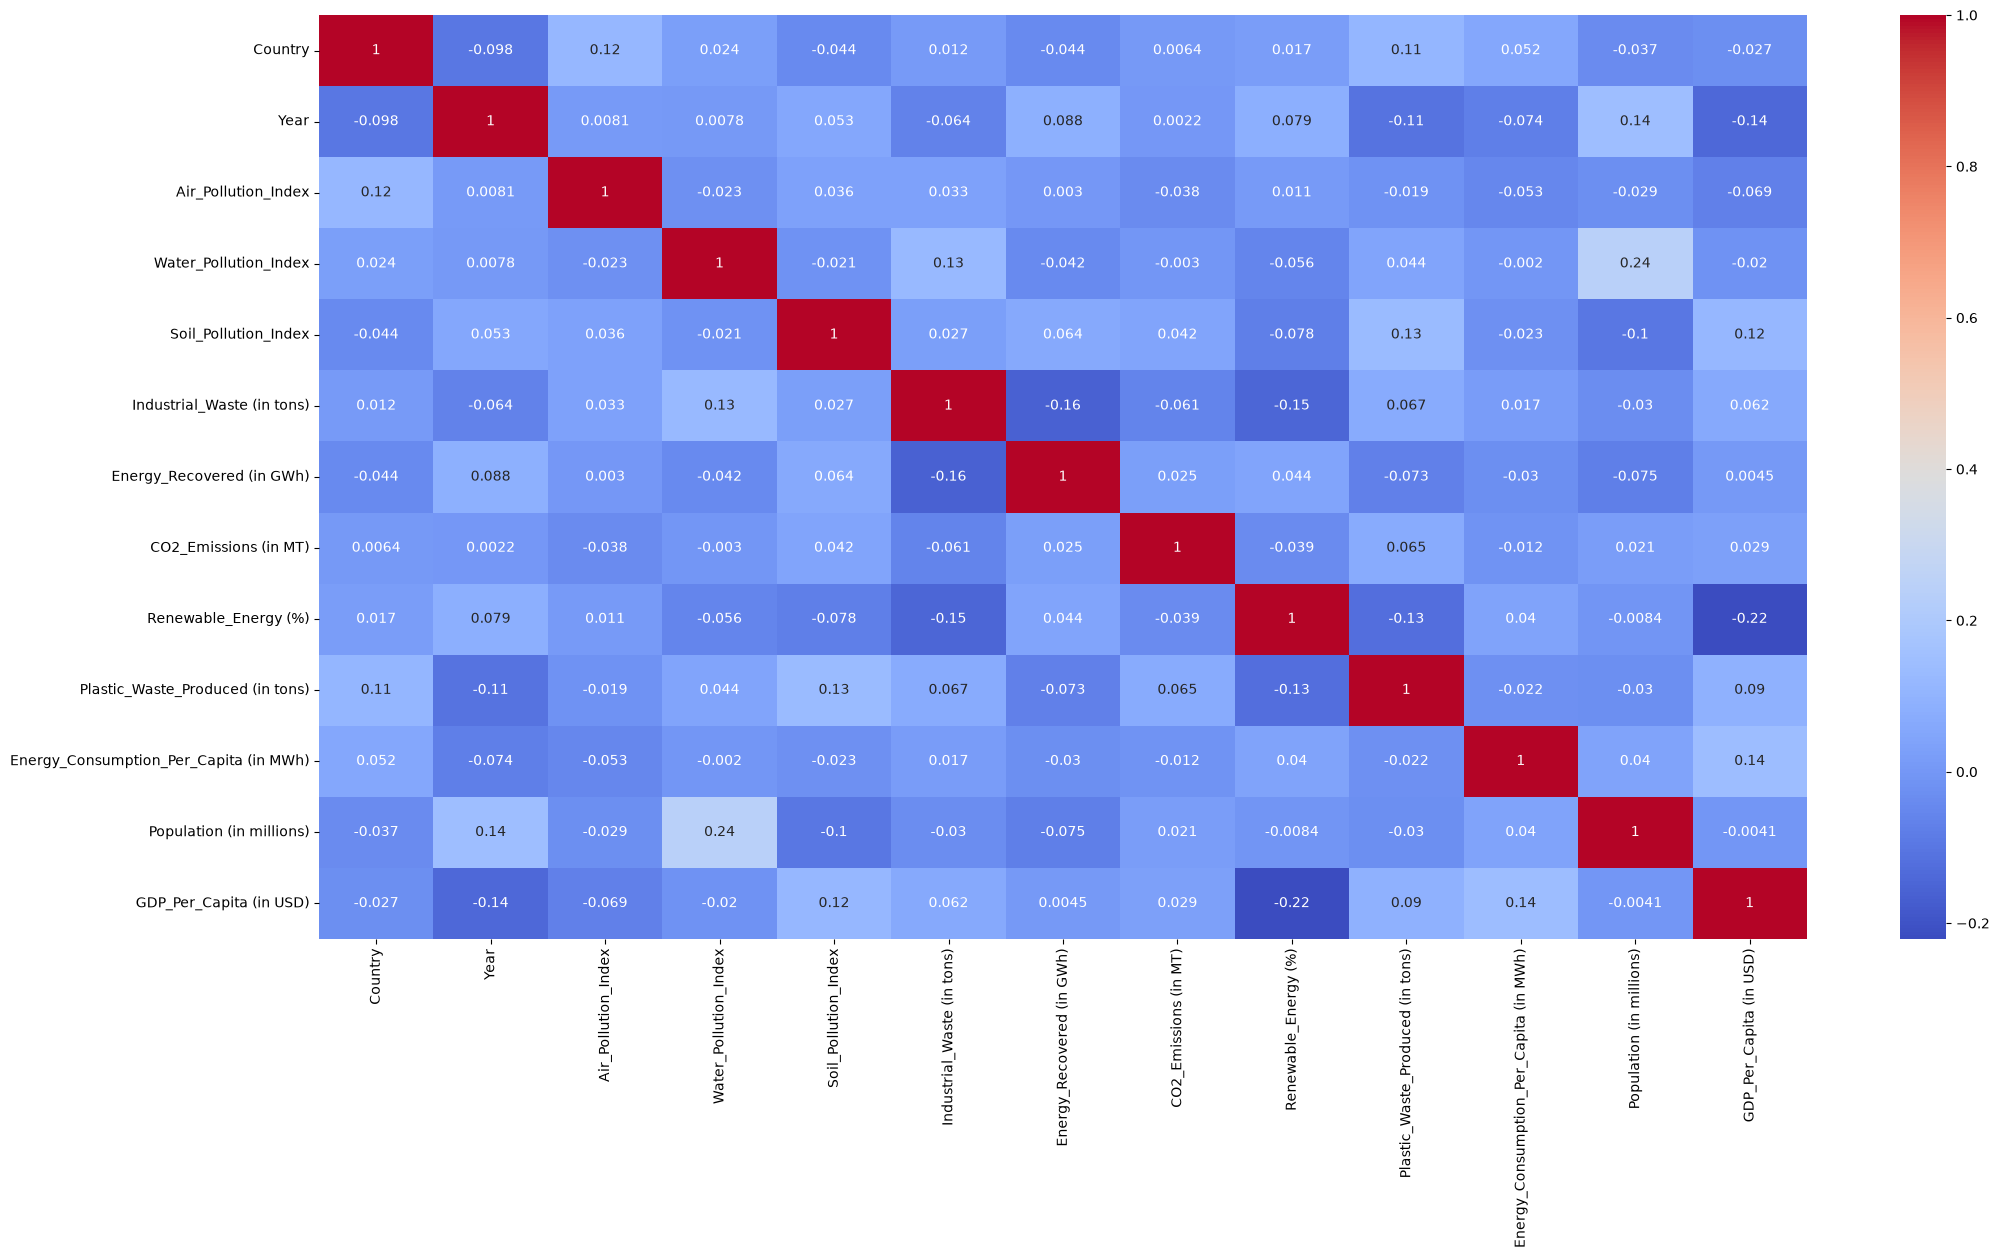

In [16]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True ,cmap = "coolwarm")

**Review of Cell 21.** Boxplots for every numeric column. **Result:** after standardization the pollution indices are roughly symmetric; waste, energy, population and GDP show wider/spread tails (potential outliers), while Year is uniform by construction.

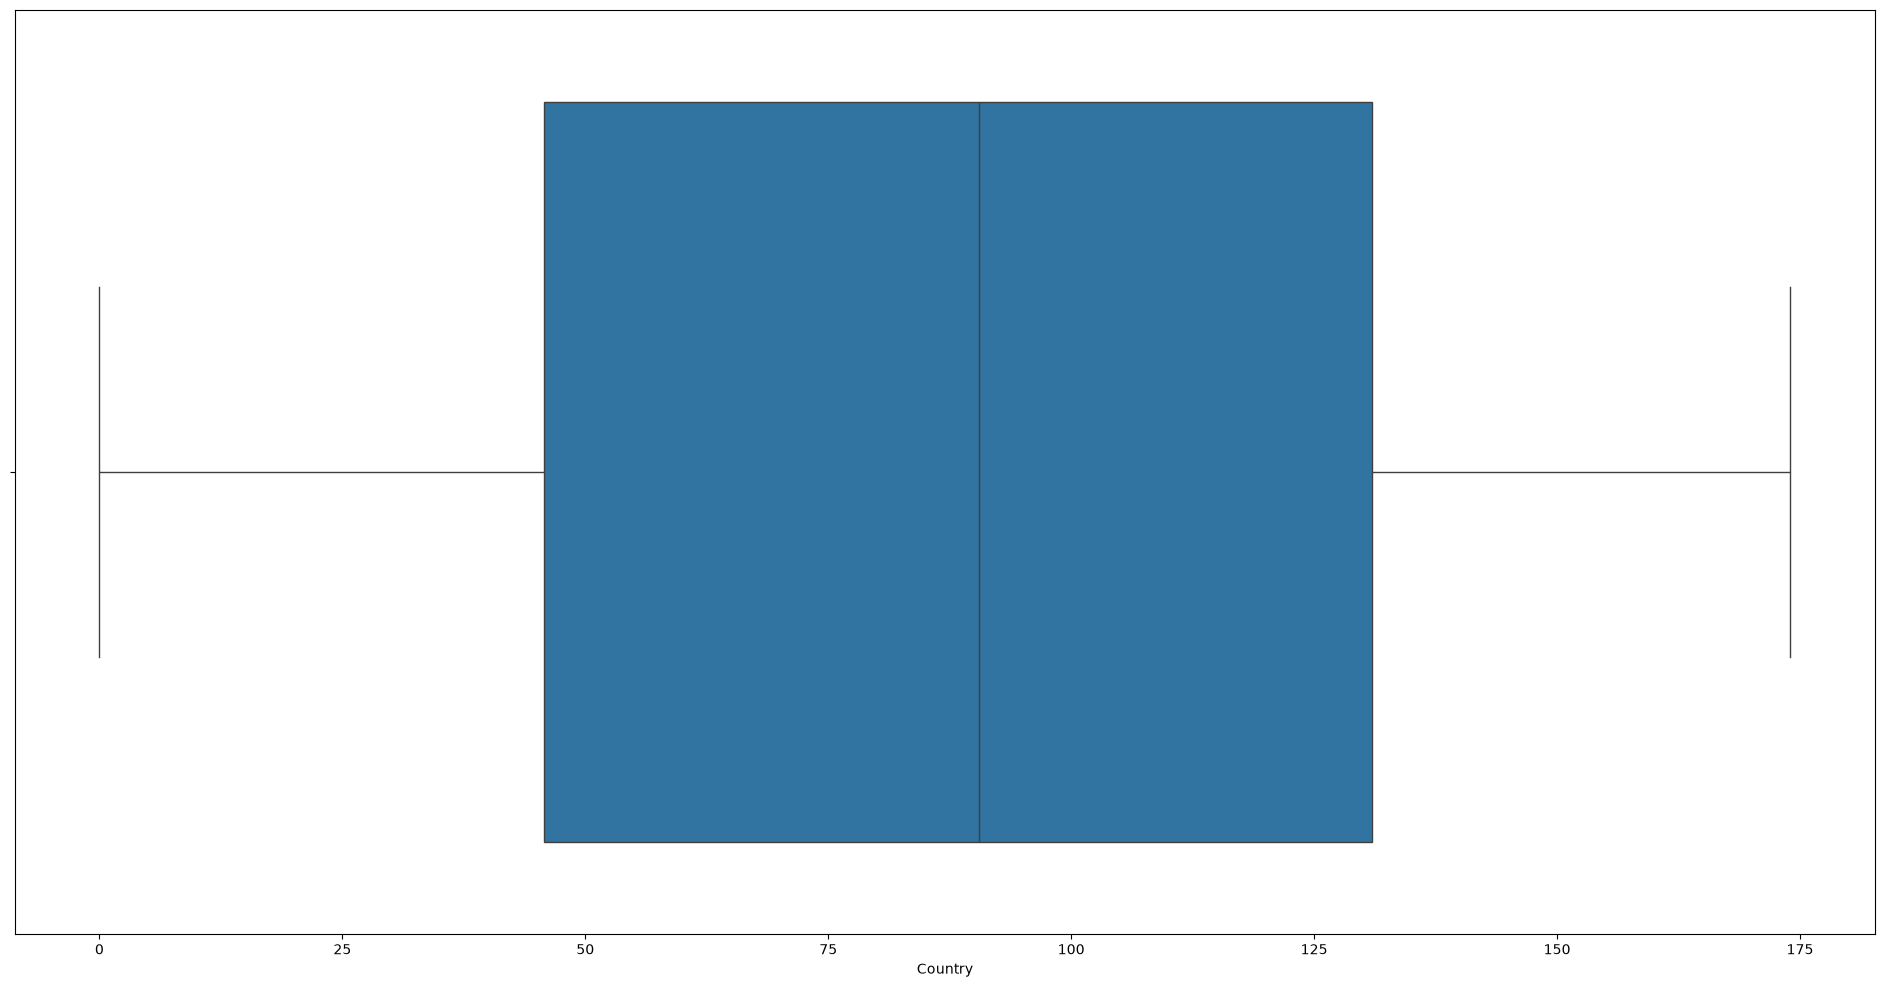

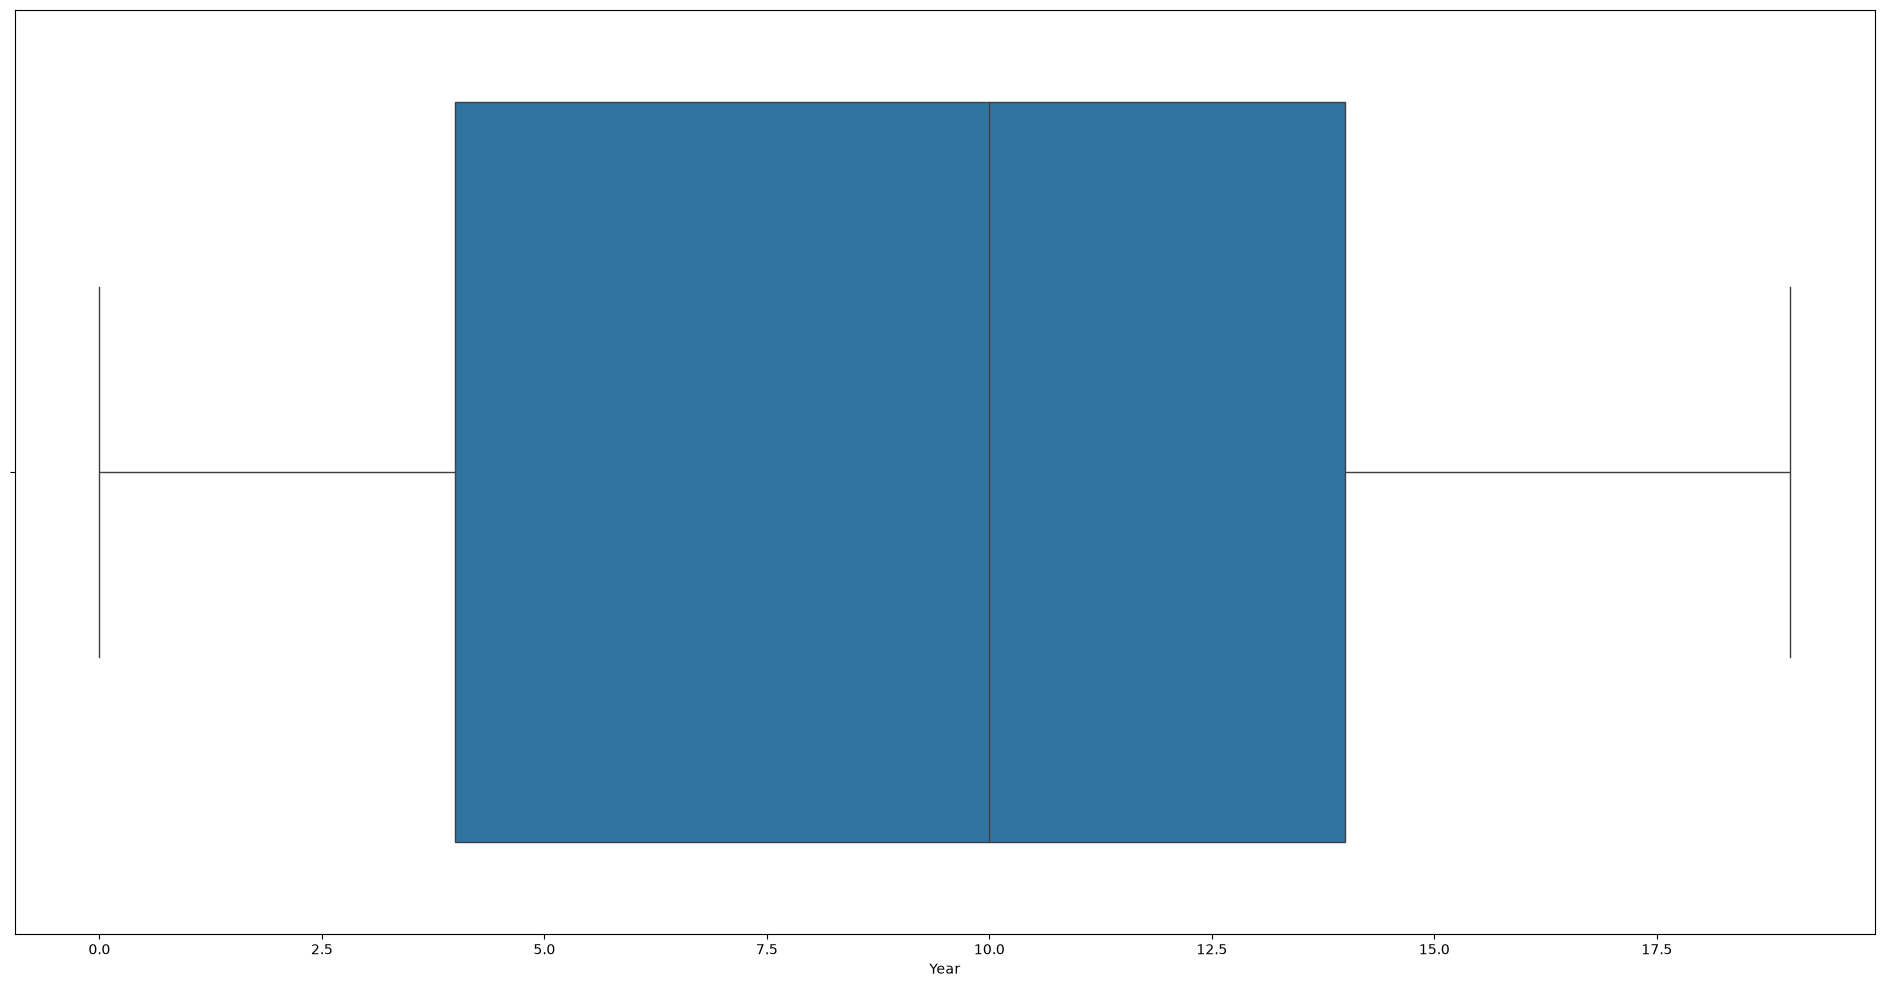

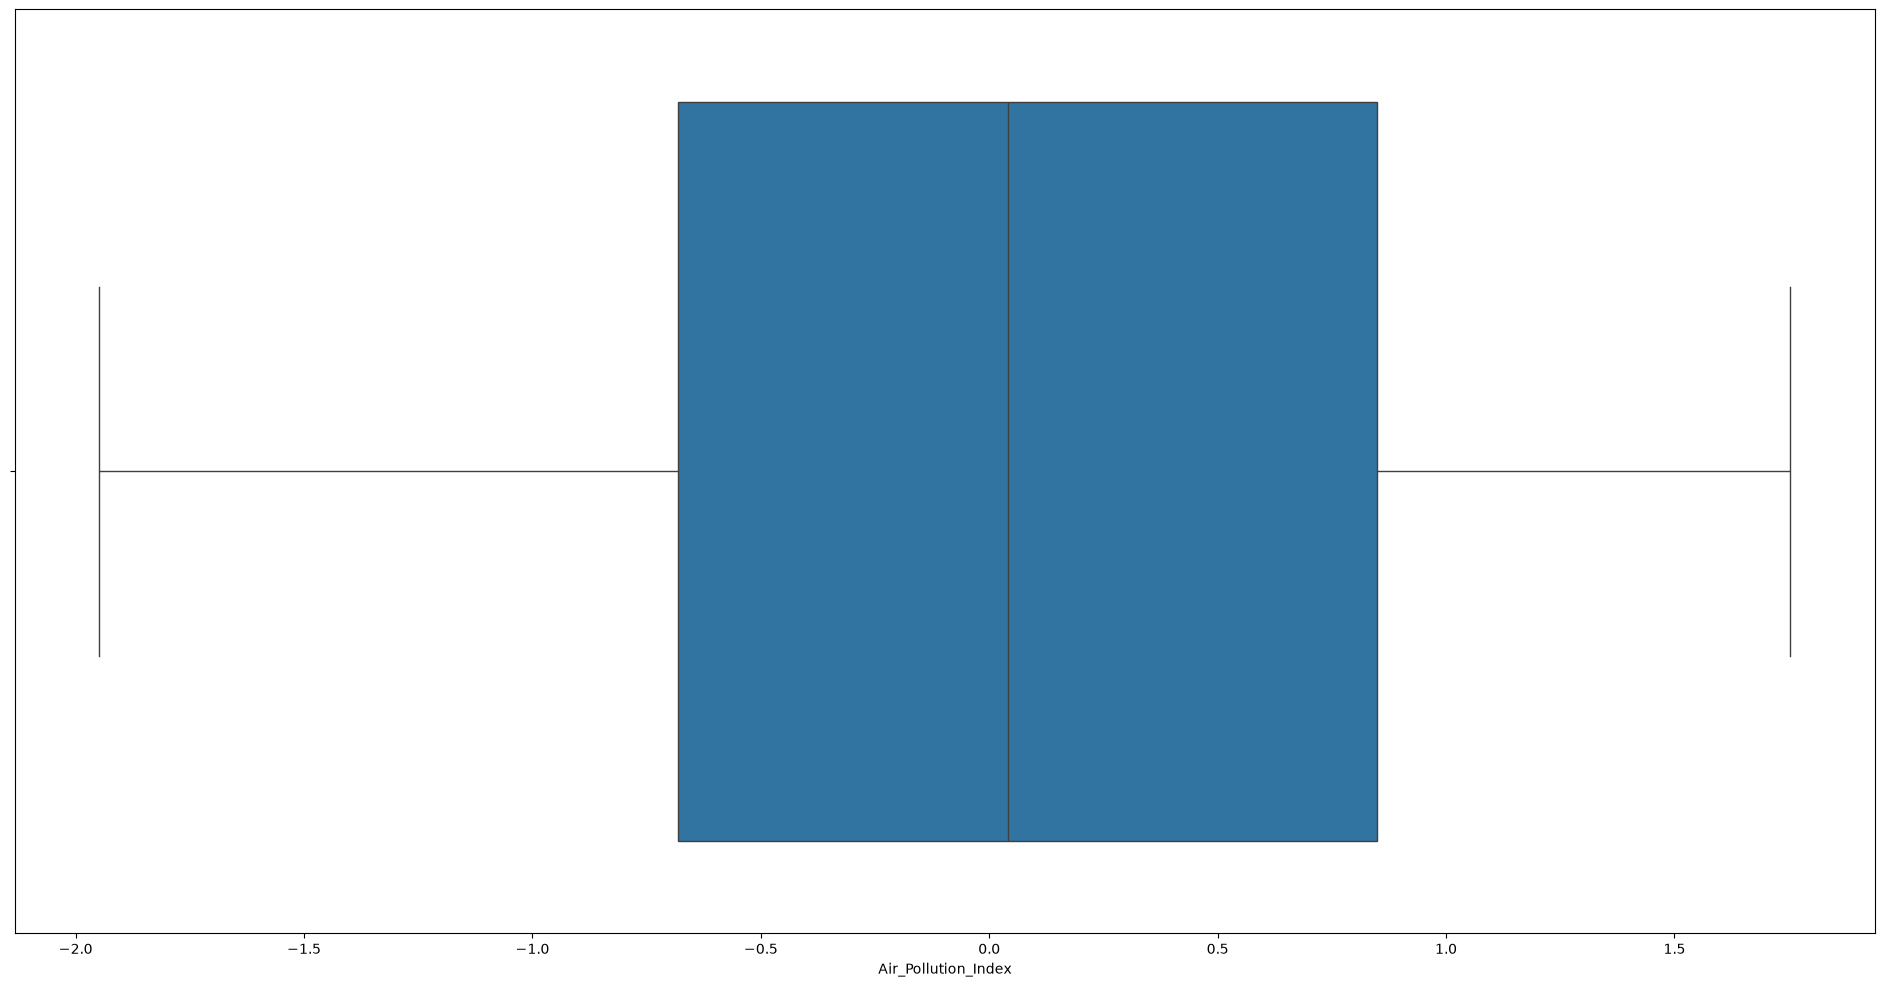

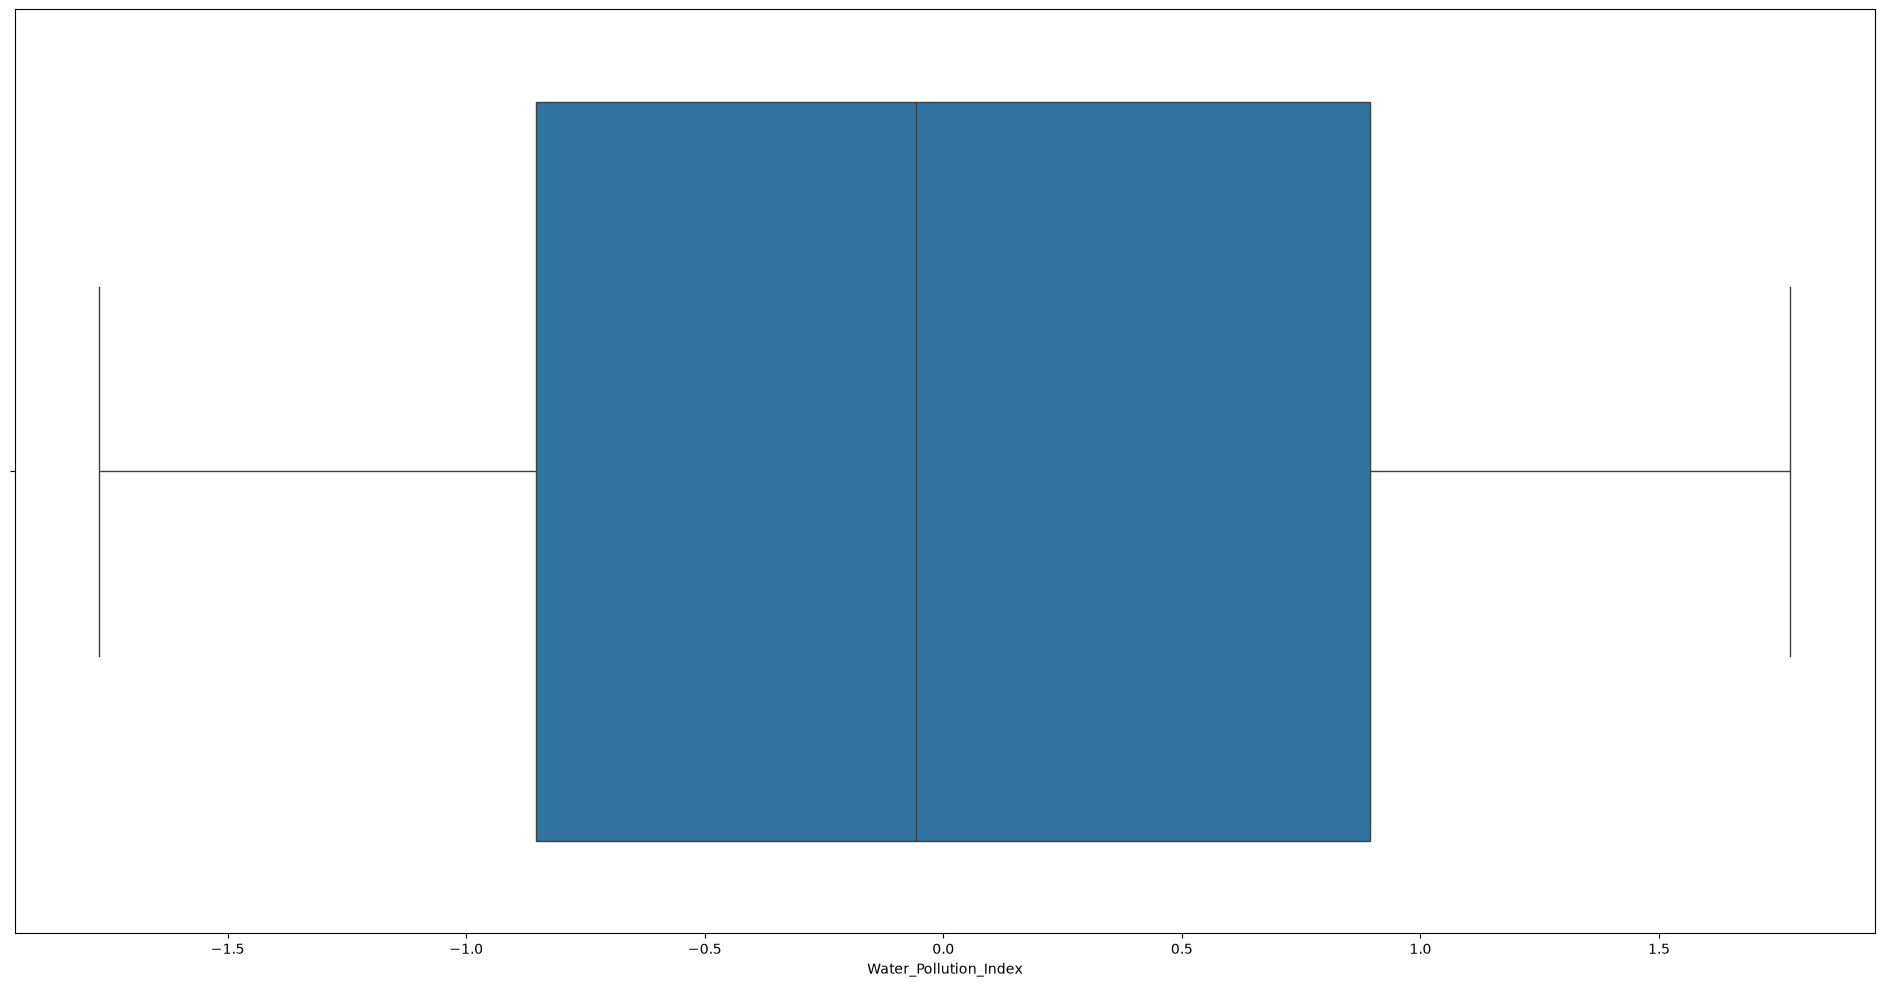

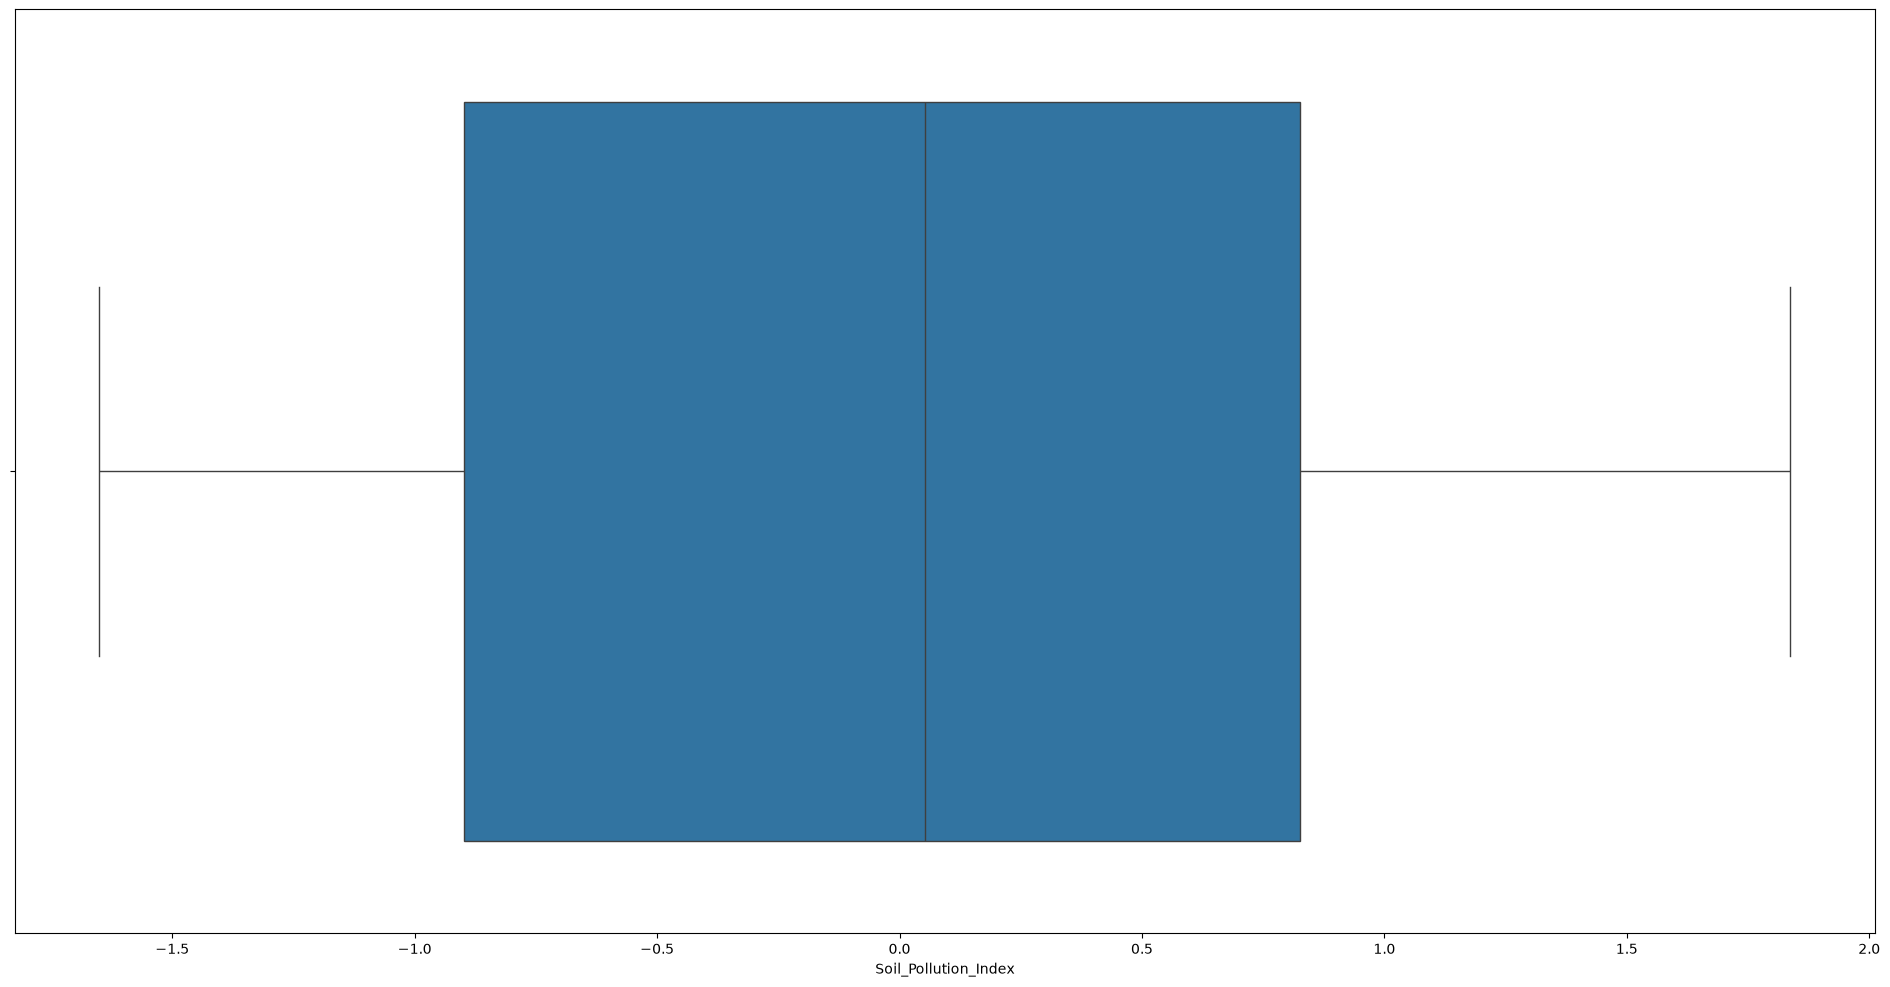

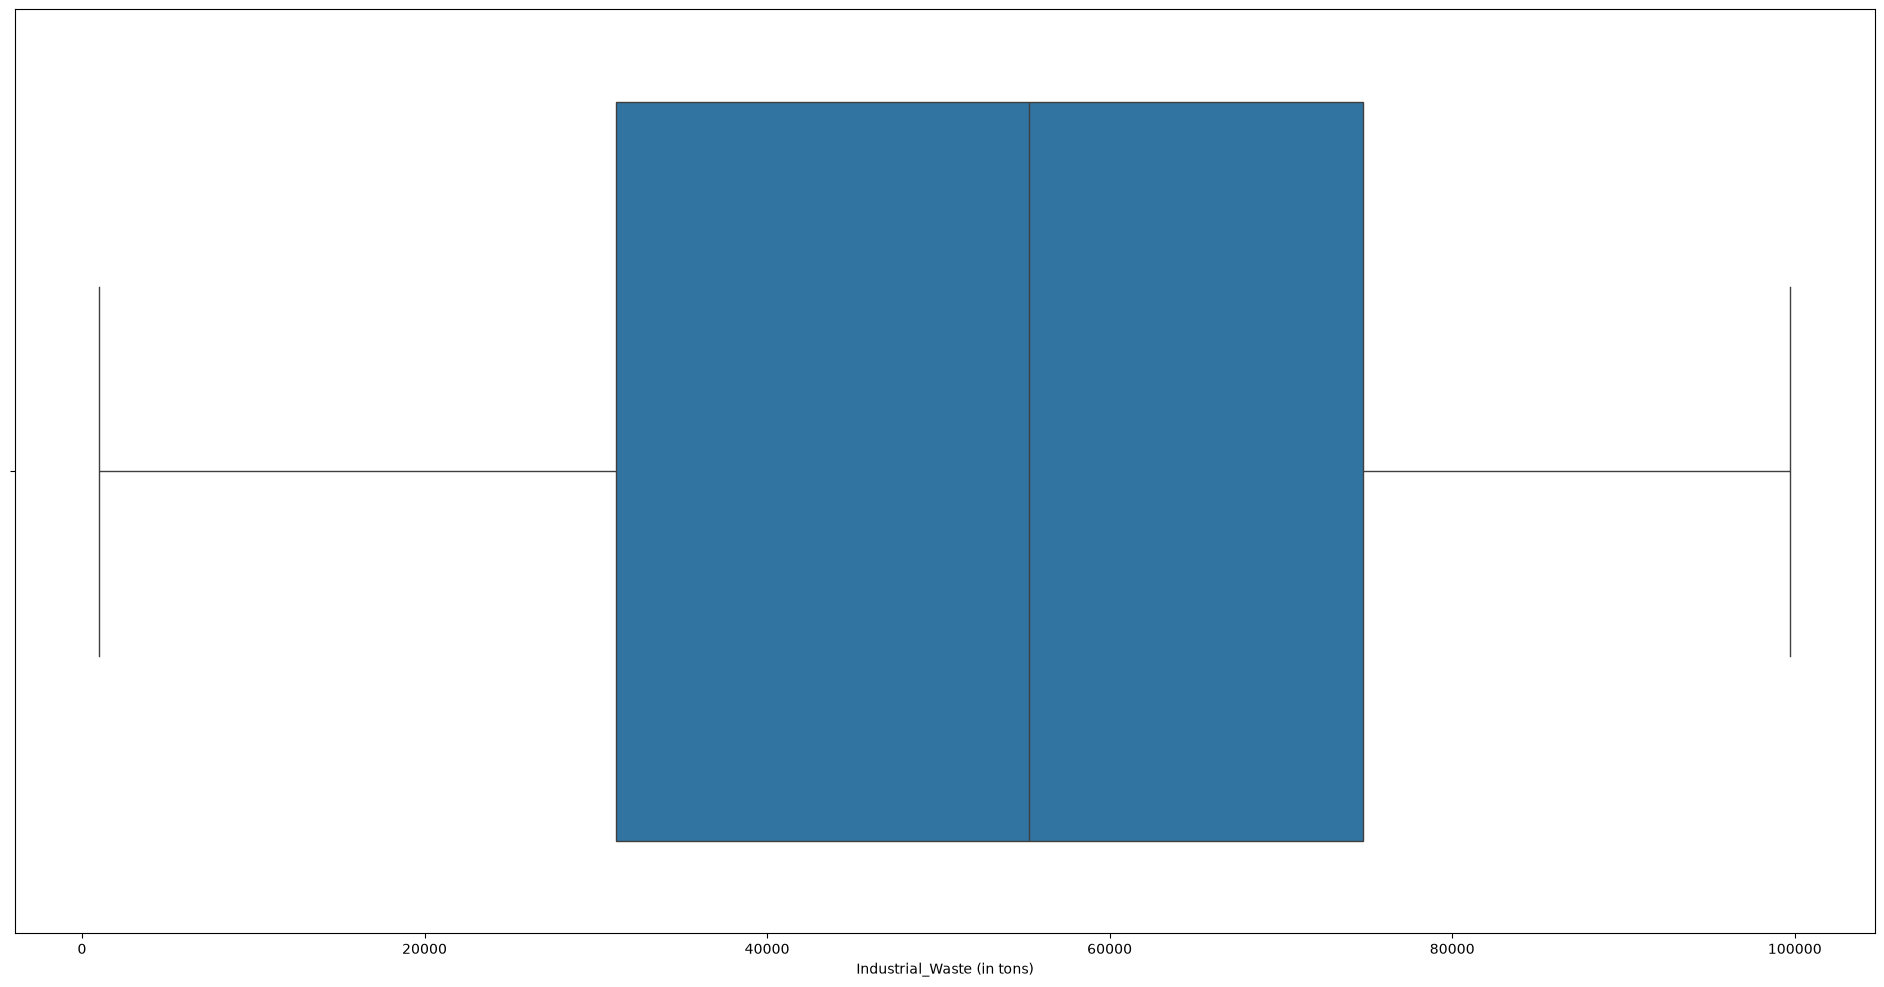

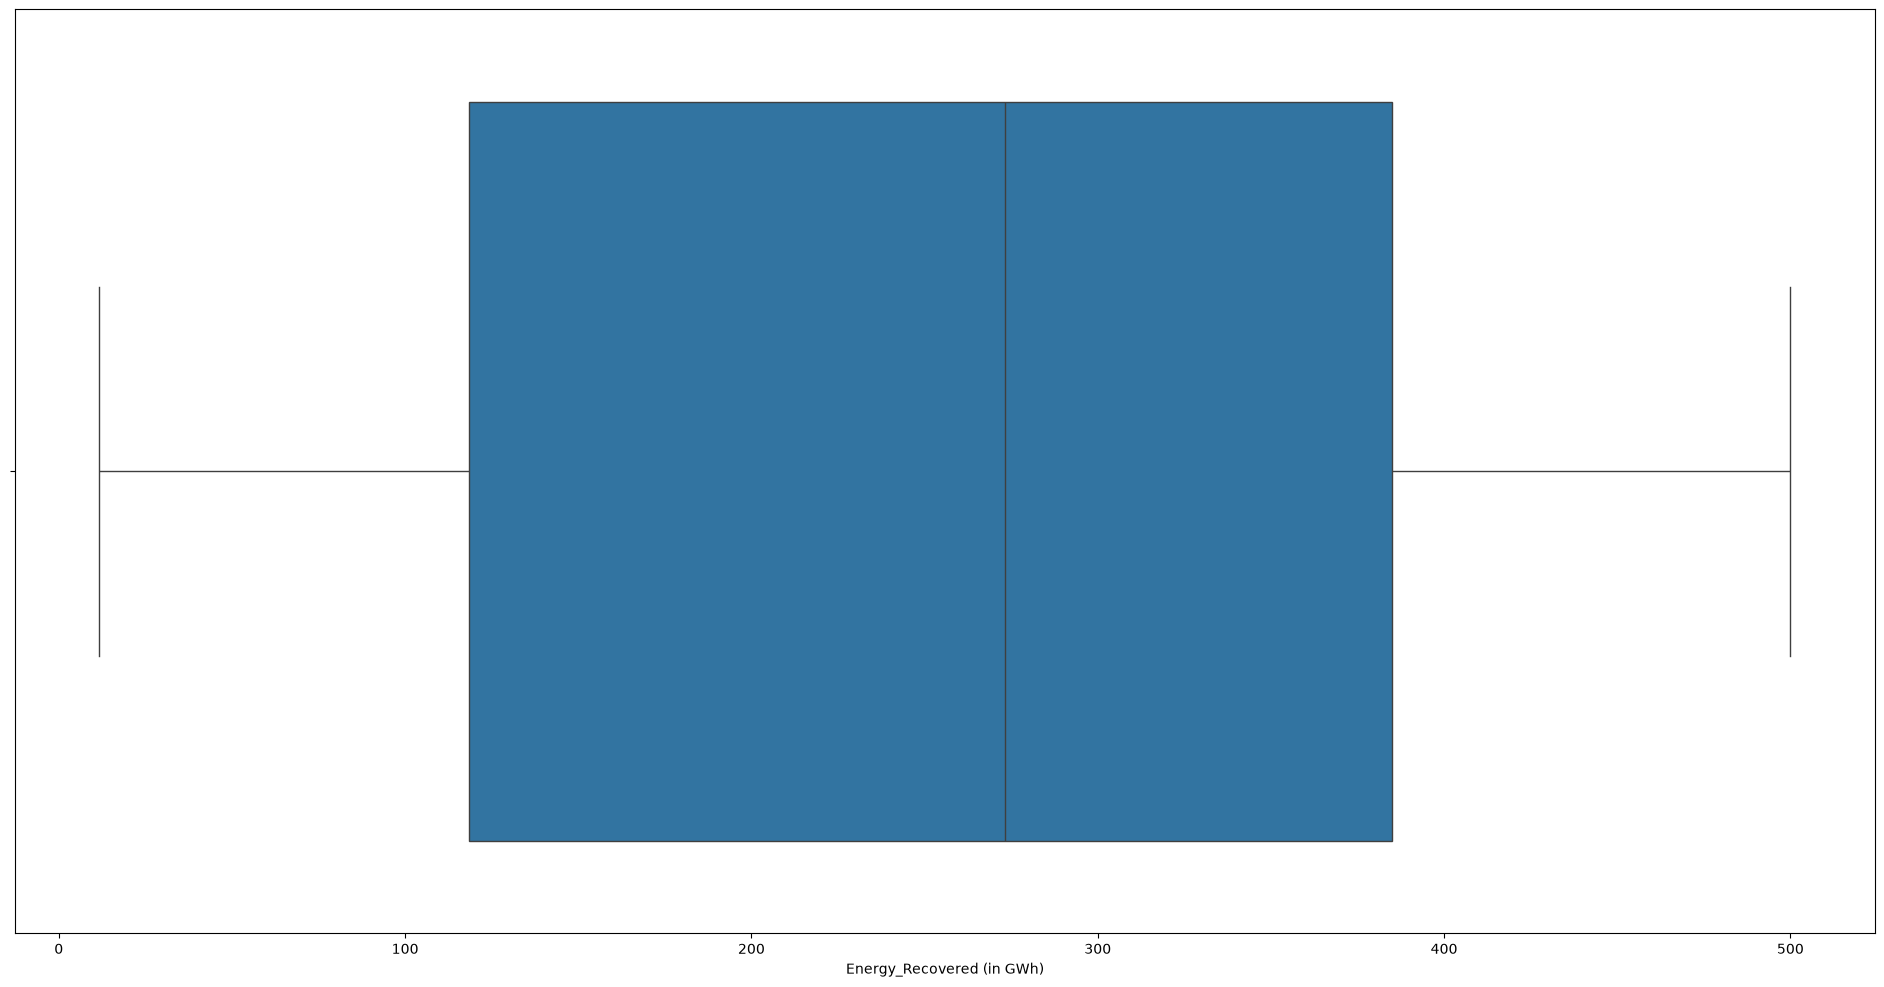

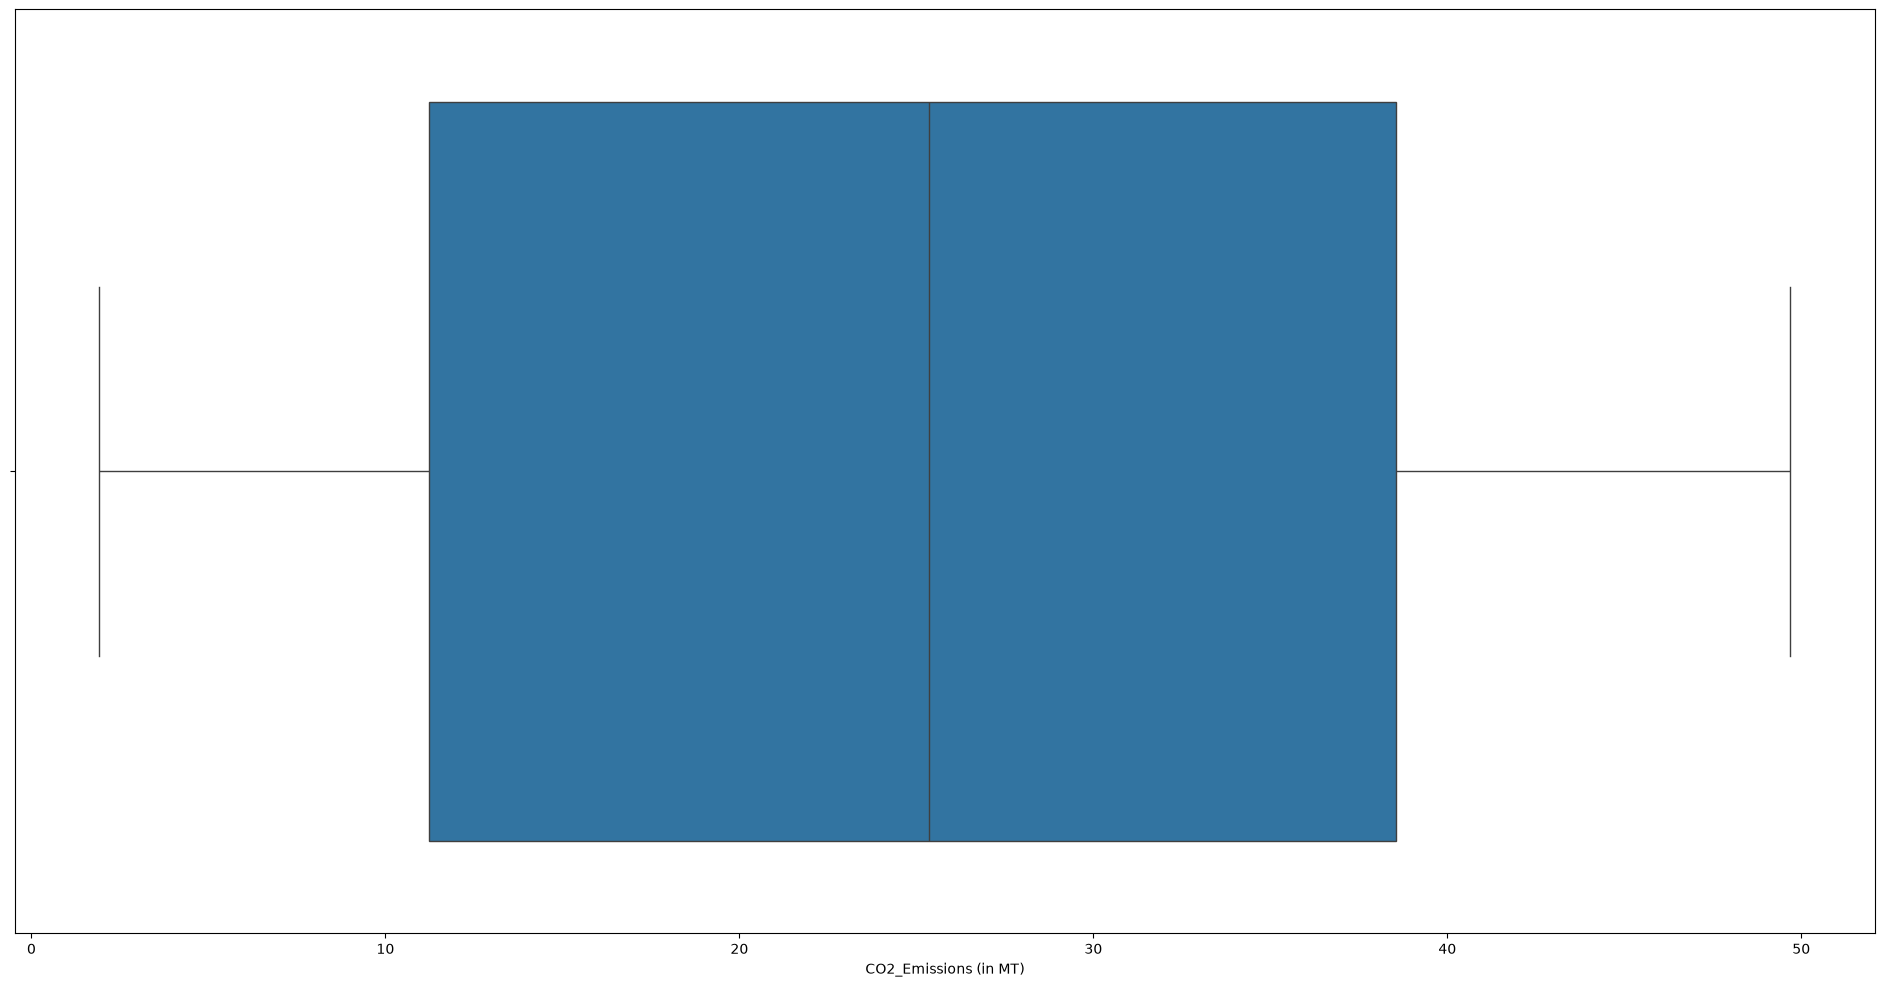

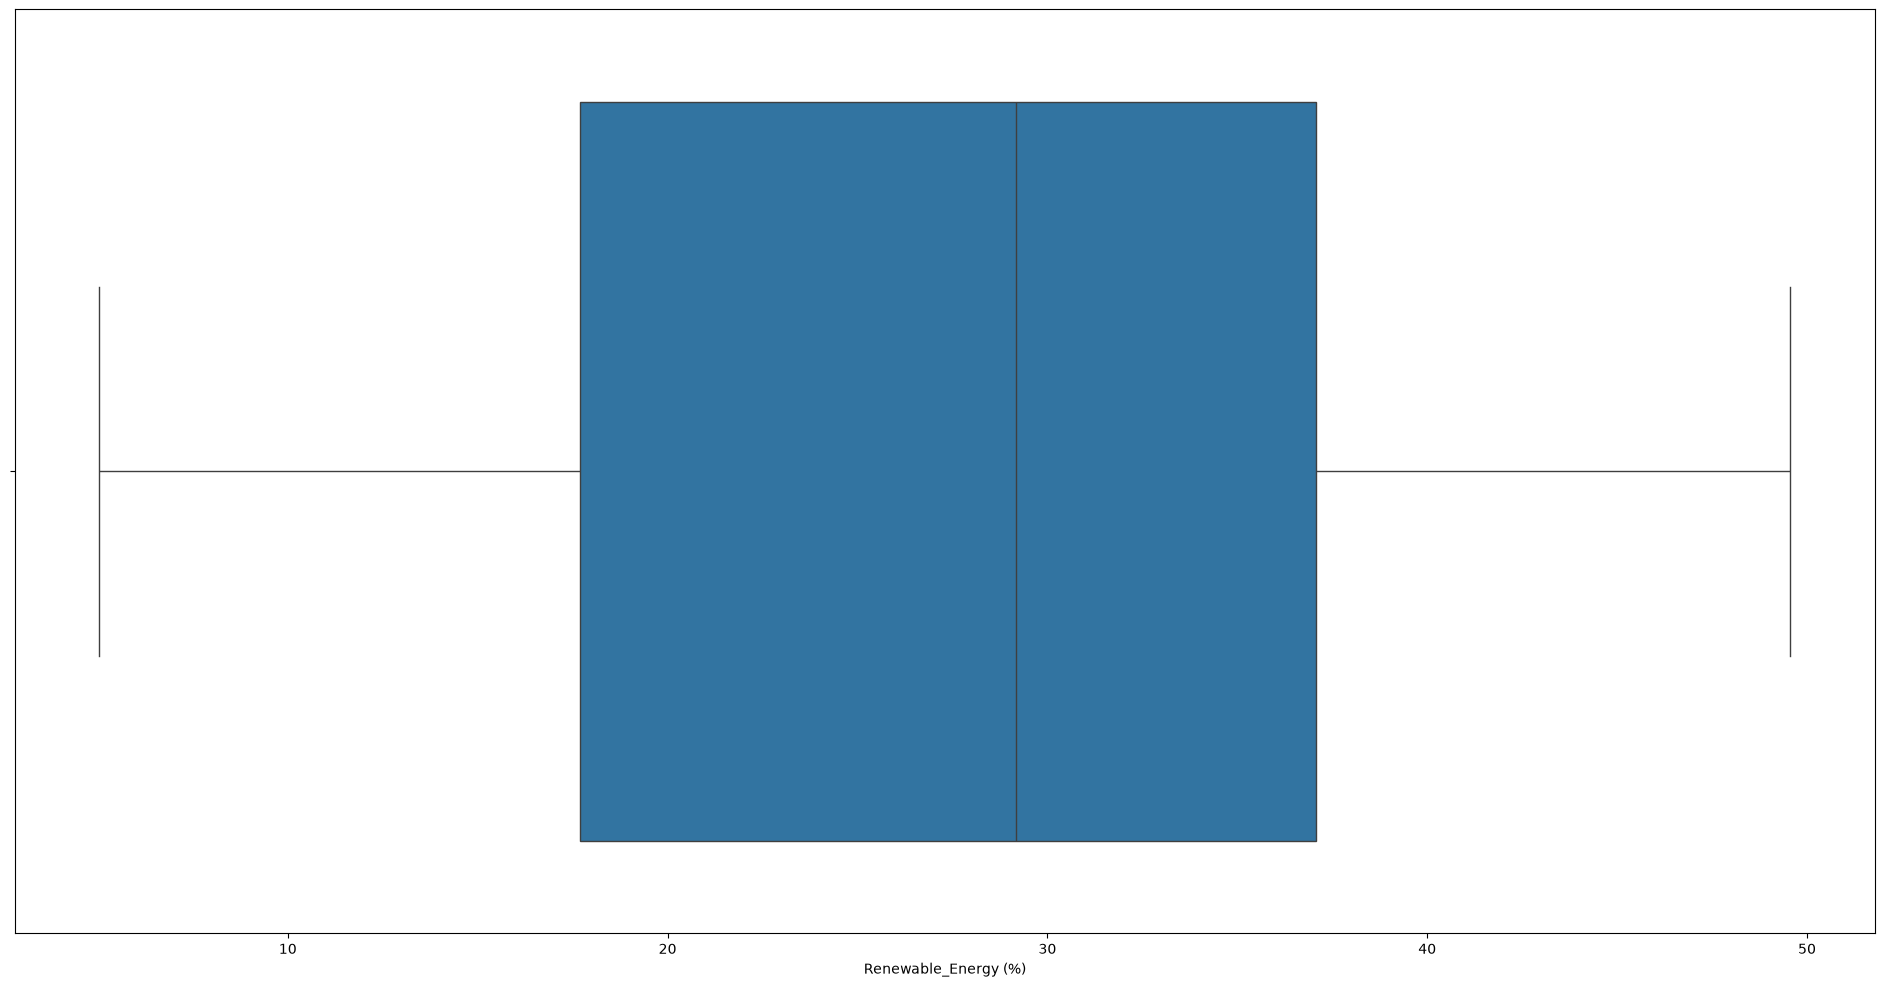

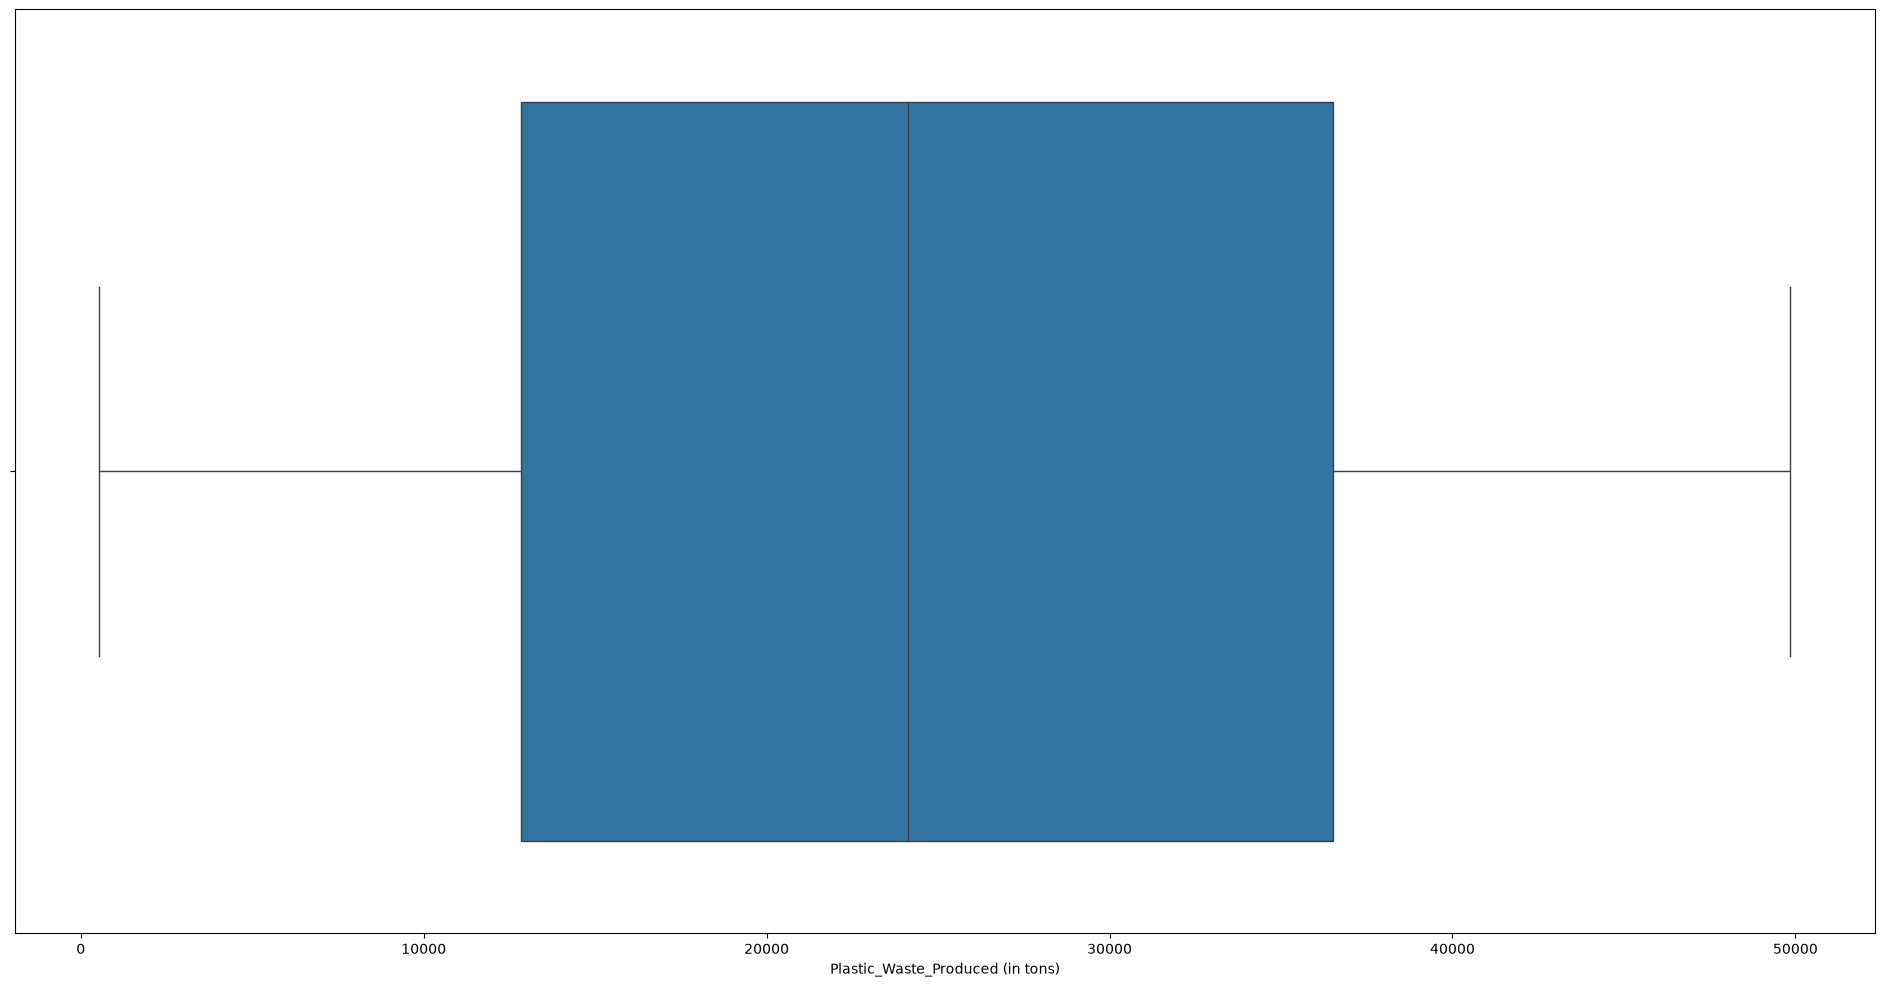

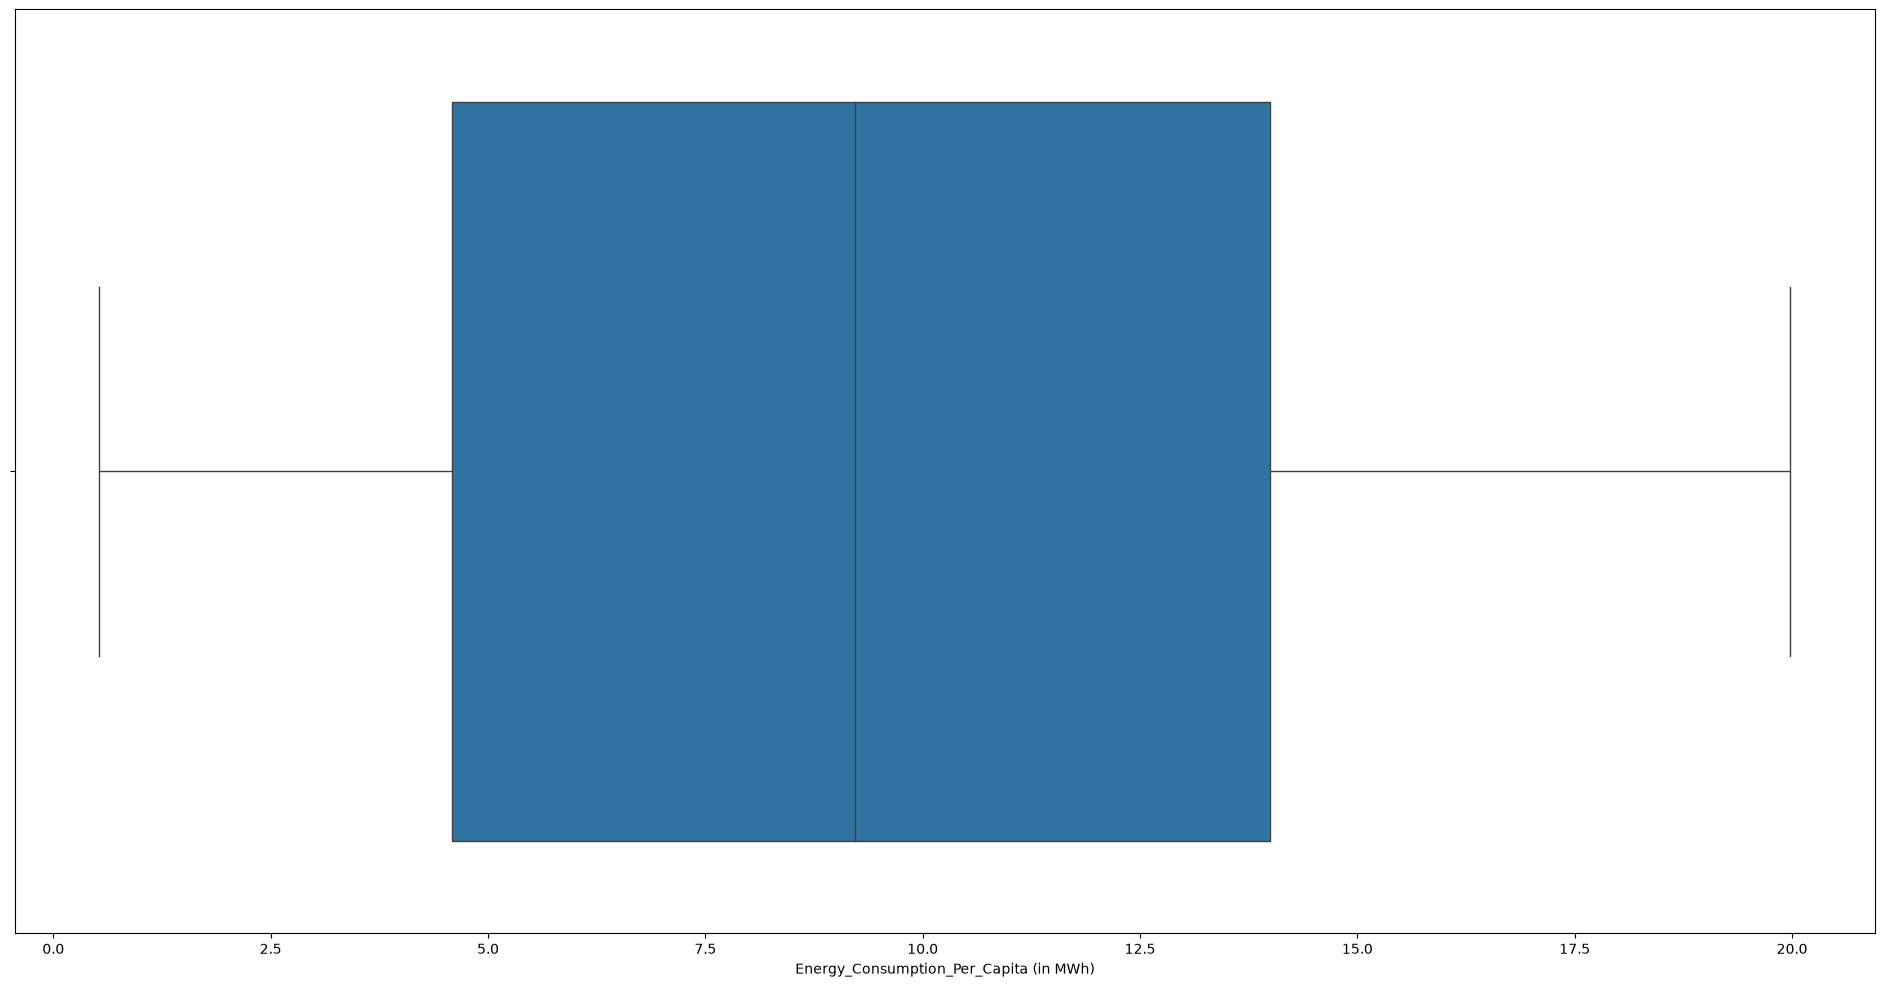

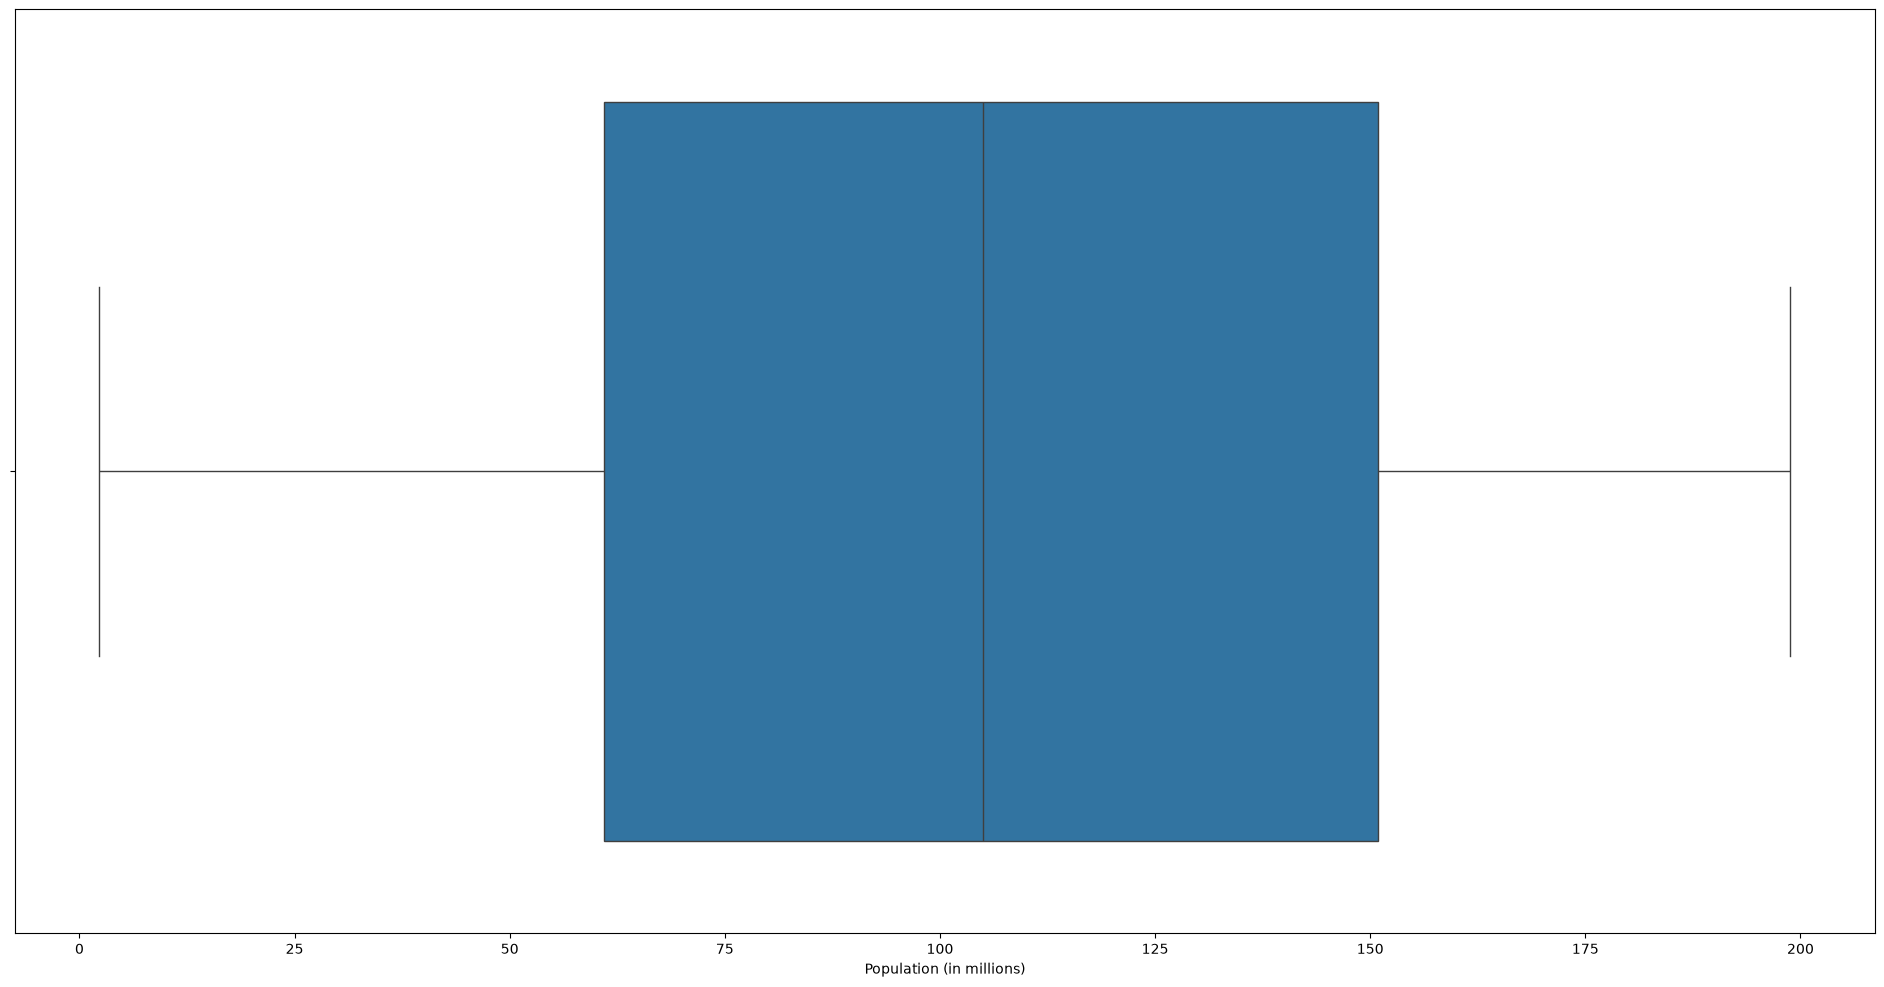

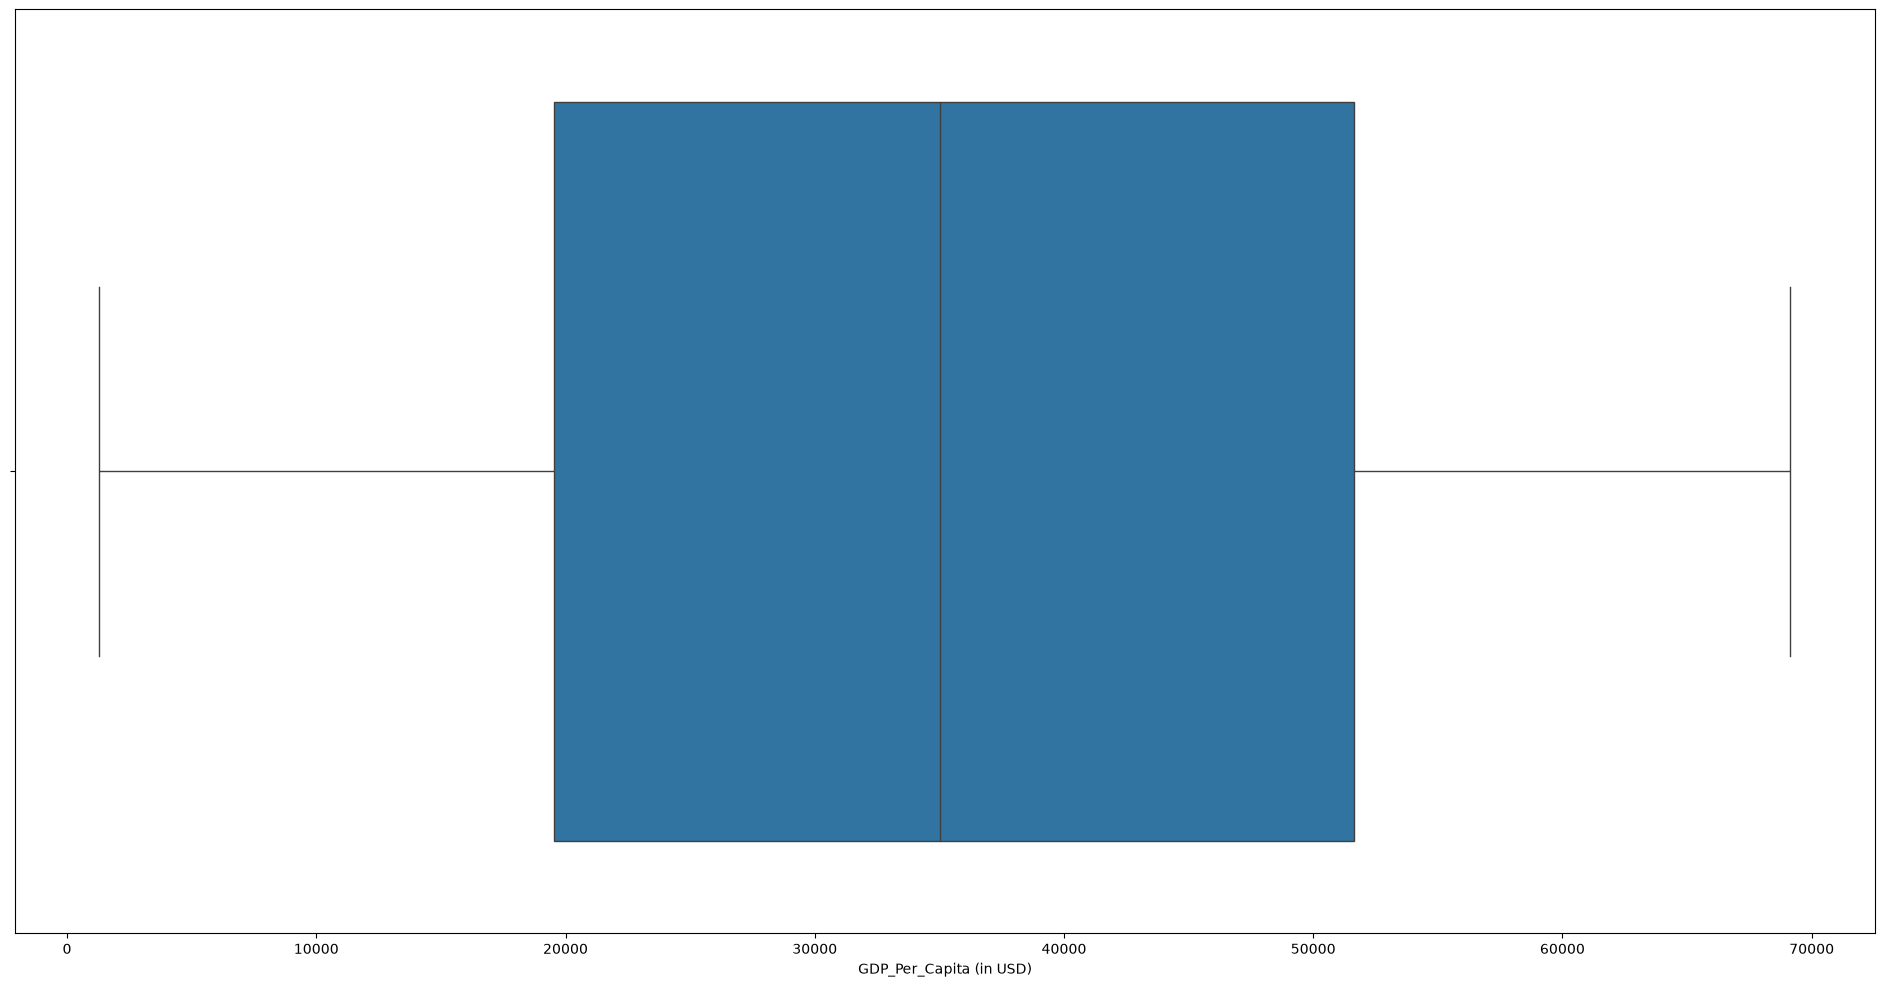

In [17]:
numeric_columns = df_new.select_dtypes(include='number').columns
for num_cols in numeric_columns:
    plt.figure(figsize=(24,12))
    sns.boxplot(x = df_new[num_cols] )

**Review of Cell 22.** Histograms with KDE for all numeric columns. **Result:** distributions are broadly unimodal; waste/CO₂/energy/GDP show dispersal across their ranges, and the scaled indices cluster around 0.

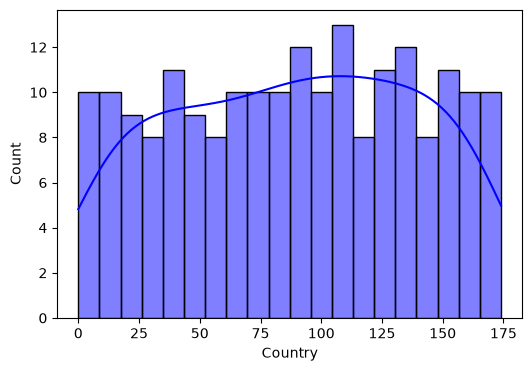

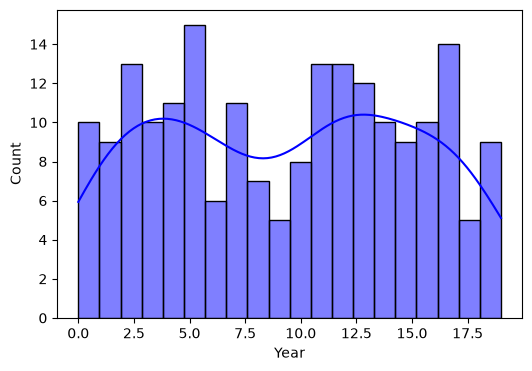

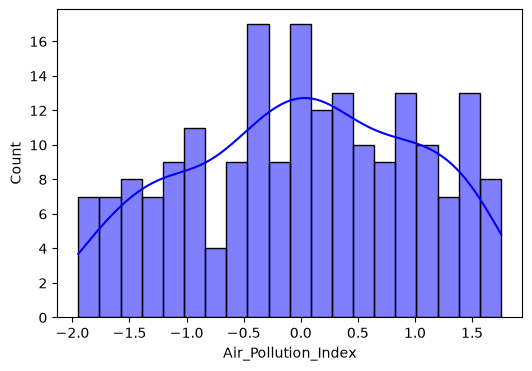

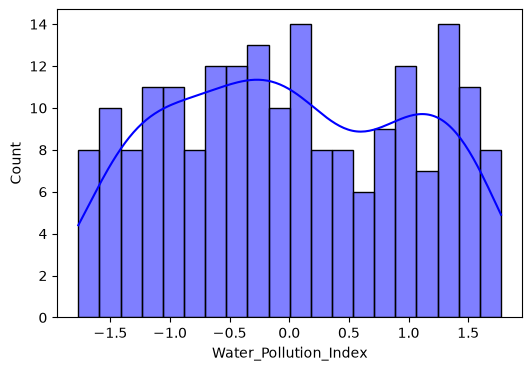

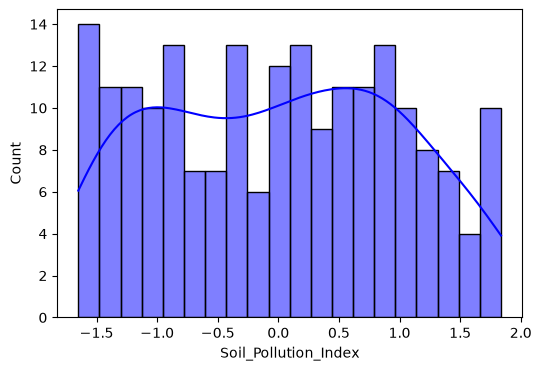

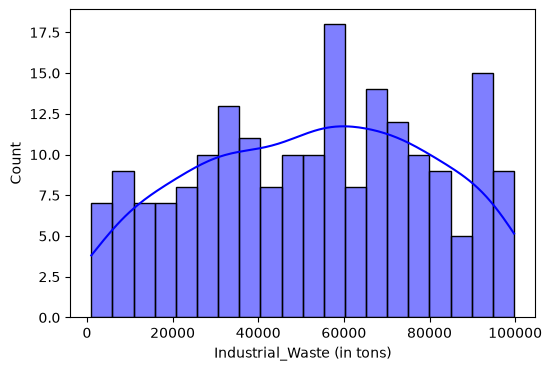

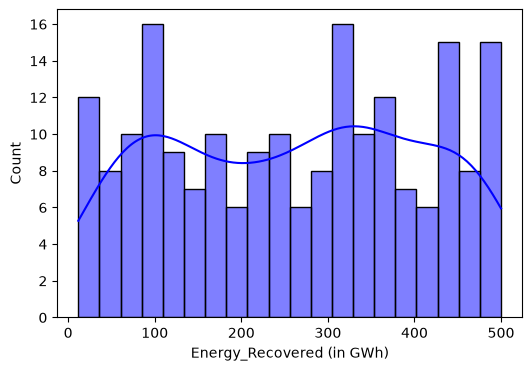

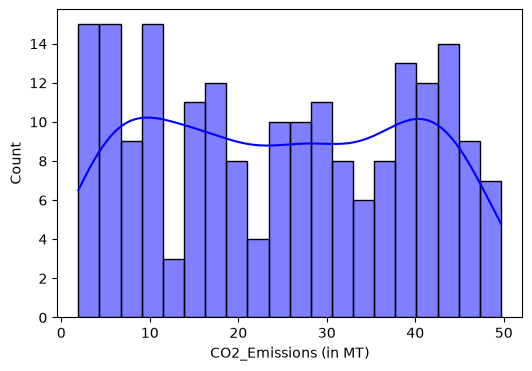

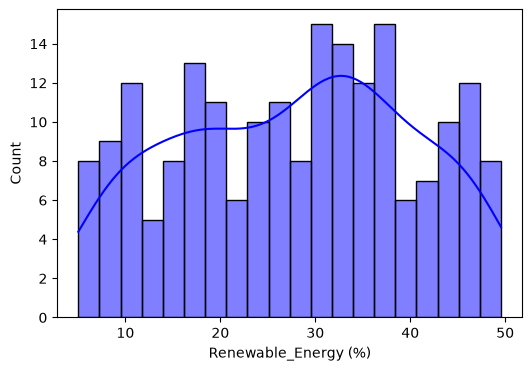

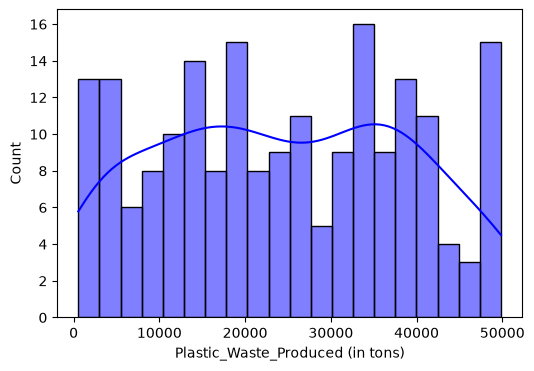

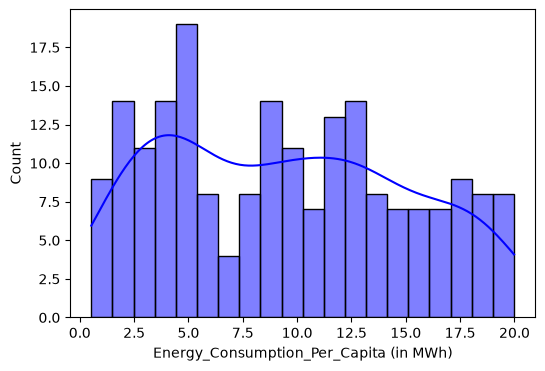

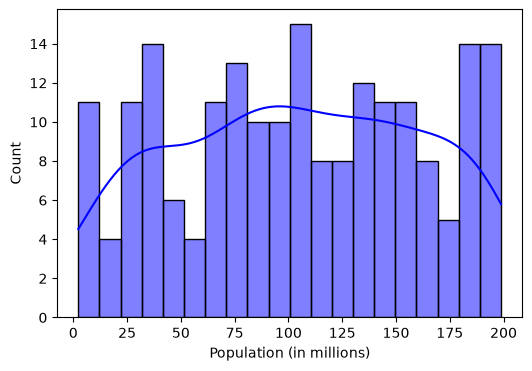

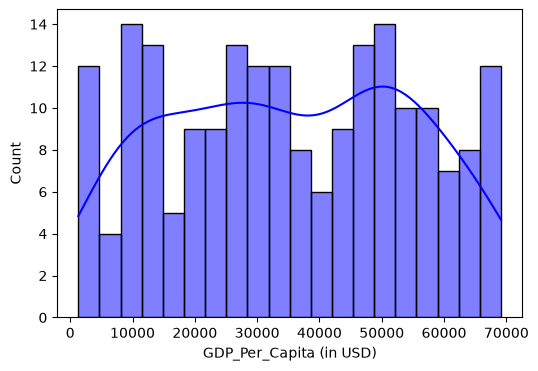

In [18]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_new[num_cols] ,kde = True,bins = 20 , color="blue"  )

**Review of Cell 23.** Time-series of the three pollution indices (2000–2019). **Result:** Air pollution oscillates the most, spiking around 2003, 2006, 2009, 2012 and reaching its **overall maximum peak in 2018**; water and soil are steadier, with soil climbing late in the period.

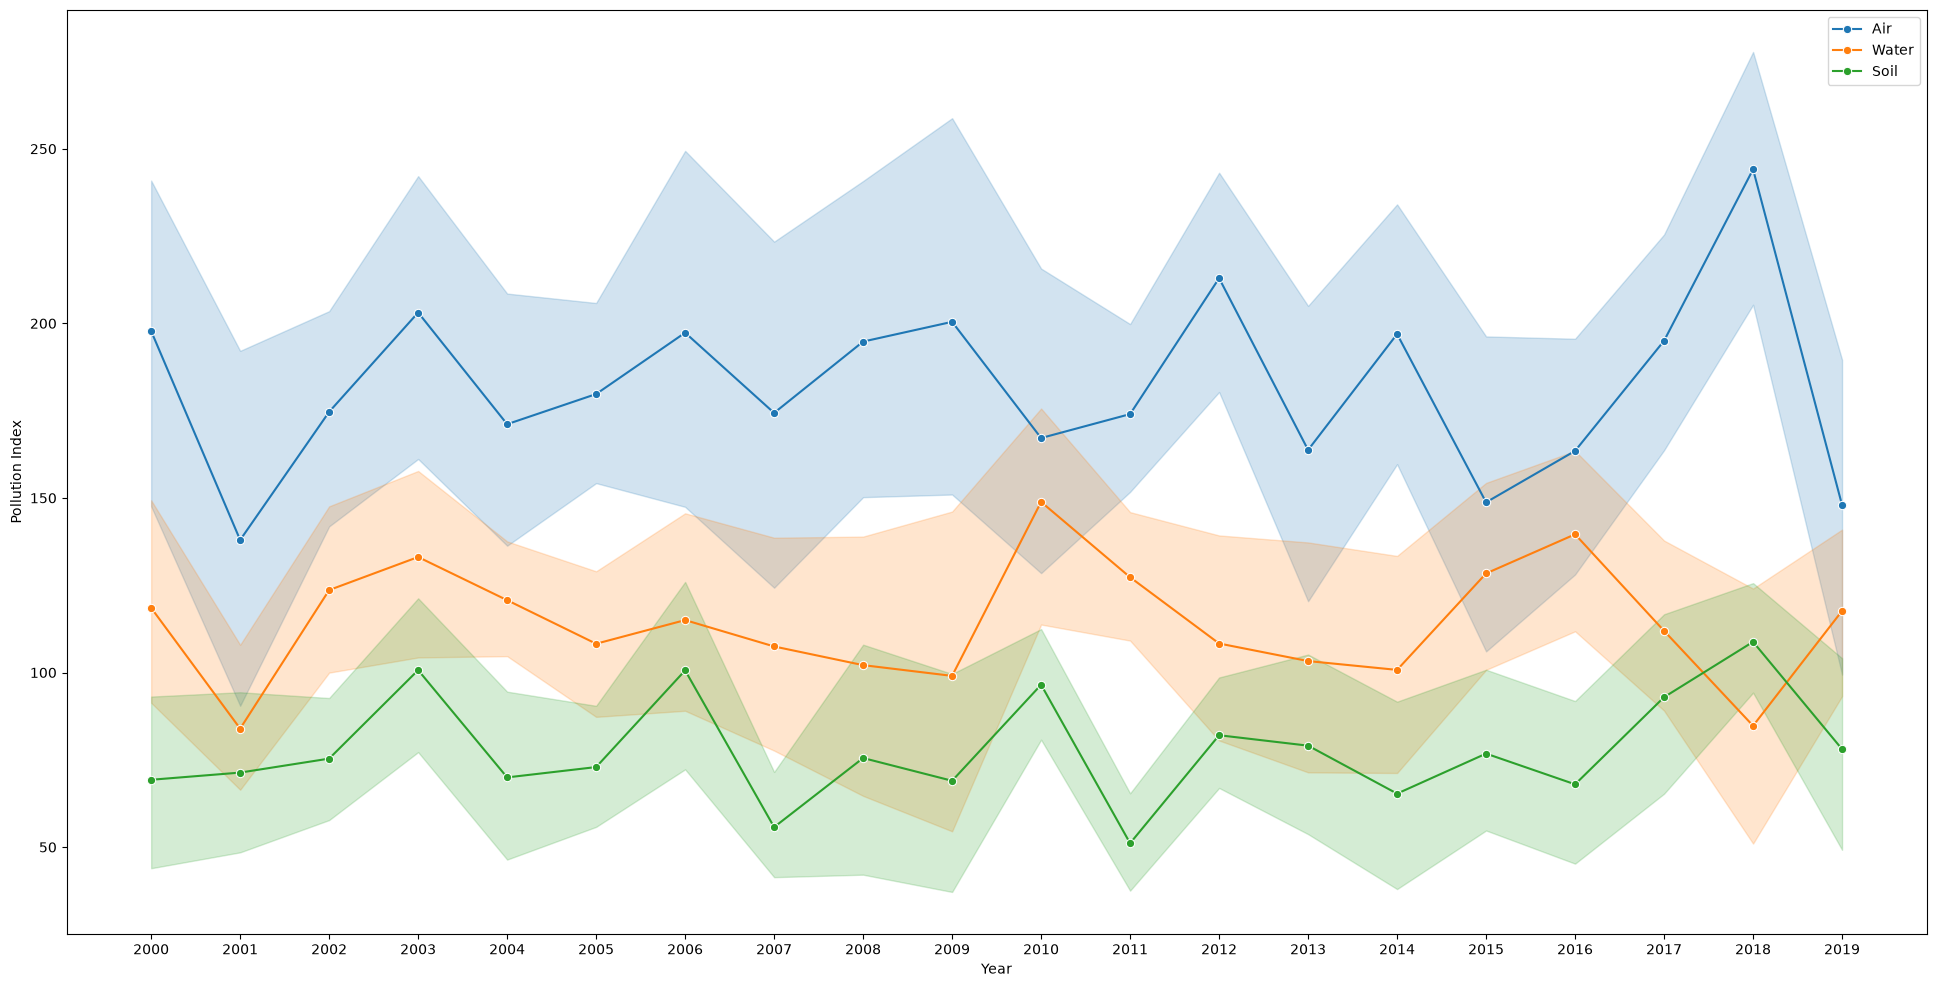

In [19]:
plt.figure(figsize=(24,12))

sns.lineplot(data=df,x='Year',y='Air_Pollution_Index',label='Air', marker='o')
sns.lineplot(data=df,x='Year',y='Water_Pollution_Index',label='Water', marker= 'o')
sns.lineplot(data=df,x='Year',y='Soil_Pollution_Index',label='Soil', marker ="o")

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

**Review of Cell 24.** Records the observation from the preceding chart (air-pollution peaks and the 2018 maximum) as a text note — used to guide the interpretation later.

---

### Observation we get :
- Air Pollution (Blue Line): Generally fluctuating more, major peaks around 2003, 2006, 2009, 2012, and a maximum overall peak in 2018.

**Review of Cell 25.** Compares yearly **industrial** vs **plastic** waste. **Result:** industrial waste runs far above plastic waste for the whole 20-year span, fluctuating between roughly 40,000 and 72,000 tons while plastic waste stays below ~45,000 tons.

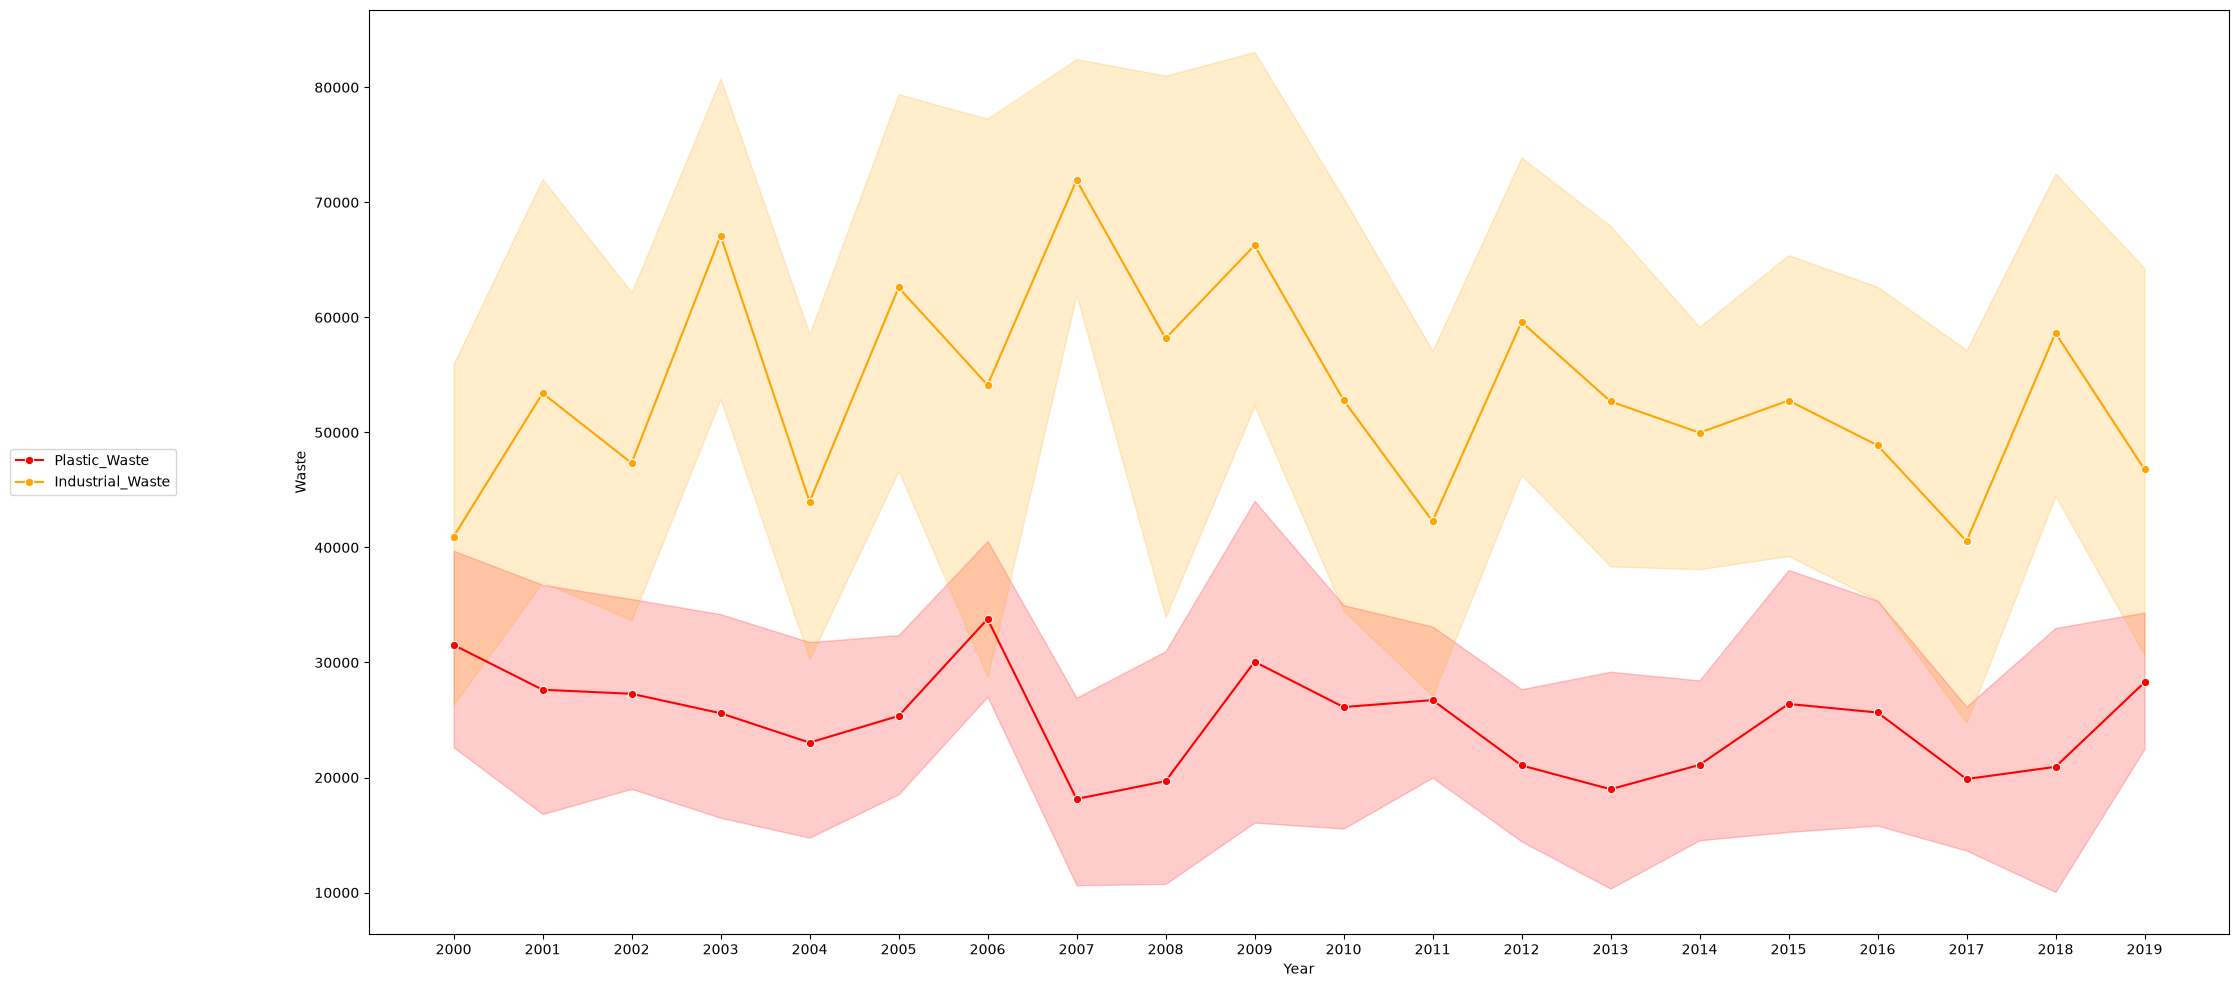

In [20]:
plt.figure(figsize=(24,12))


sns.lineplot(data=df,x='Year',y='Plastic_Waste_Produced (in tons)',label='Plastic_Waste', marker= 'o' , color='red')
sns.lineplot(data=df,x='Year',y='Industrial_Waste (in tons)',label='Industrial_Waste', marker ="o", color='orange')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Waste")

plt.legend(loc='center right', bbox_to_anchor=(-0.1, 0.5))
plt.show()


**Review of Cell 27.** Time-series of **CO₂ emissions** (in MT). **Result:** emissions undulate between ~18 and 34 MT across 2000–2019 with no monotonic rise or fall — roughly stationary vibration around the mean.

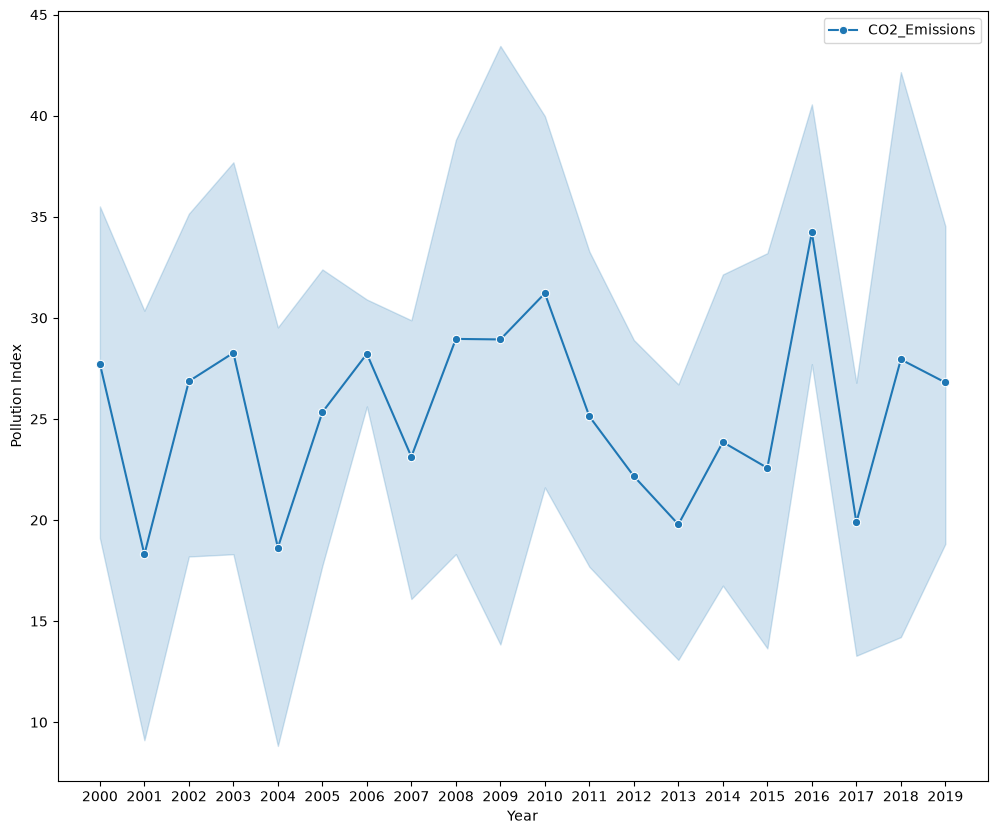

In [21]:
plt.figure(figsize=(12,10))

sns.lineplot(data=df,x='Year',y='CO2_Emissions (in MT)',label='CO2_Emissions', marker='o')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

**Review of Cell 29 (Feature Engineering, Step 3 start).** Engineers a new feature `Average_Pollution` = mean of the air, water and soil indices — a convenient single numeric proxy for overall pollution in a country-year.

In [22]:
df['Average_Pollution'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

**Review of Cell 30.** Aggregates `Average_Pollution` by country (mean over years) and plots the **Top-10 most polluted countries** for policy prioritization. **Result (top of the ranking):** Saint Barthélemy (187.0), Bolivia (181.5), Central African Republic (177.0), Christmas Island (176.0), Papua New Guinea (175.7), Guinea-Bissau (175.3), Morocco (174.3), Philippines (173.6), Saint Lucia (173.6), Argentina (173.1). These should receive priority in pollution-control, renewables and waste-management programs.

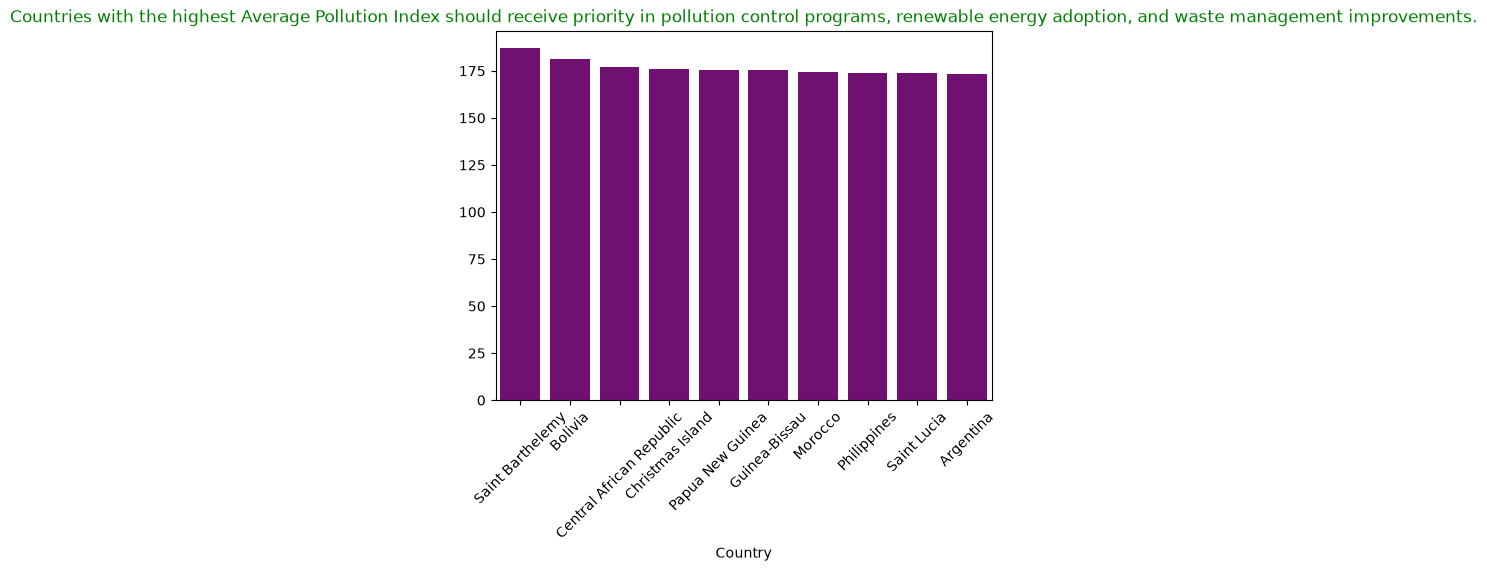

In [23]:
top10 = df.groupby('Country')['Average_Pollution'].mean().sort_values(ascending=False).head(10) # take help here :)

sns.barplot(x=top10.index, y=top10.values , color='purple')
plt.xticks(rotation=45)
plt.title("Countries with the highest Average Pollution Index should receive priority in pollution control programs, renewable energy adoption, and waste management improvements.", color="green")
plt.show()

In [24]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


**Review of Cell 33.** Builds `yearly_trends`: mean of the pollution indices, average pollution and energy recovered **per year**. **Result:** shows the cross-year macro pattern used for the trend plot — e.g. 2000: avg pollution 128.5, energy recovered 296.9 GWh.

In [25]:
yearly_trends = df.groupby("Year" , as_index=False)[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Average_Pollution",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Average_Pollution,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,128.530667,296.889000
1,2001,137.964444,83.933333,71.340000,97.745926,288.877778
2,2002,174.661538,123.617692,75.344615,124.541282,259.750769
3,2003,203.103000,133.080000,100.687000,145.623333,208.139000
4,2004,171.120909,120.719091,69.959091,120.599697,186.458182


**Review of Cell 34.** Plots yearly averages of pollution vs energy recovered. **Result:** while average pollution fluctuates upward (especially near 2018), energy recovered **declines** across the period — an inverse visual relationship between the two series.

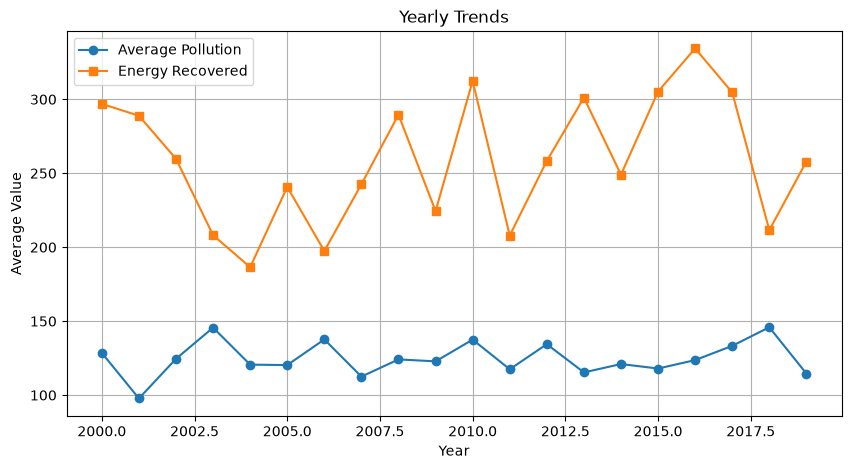

In [26]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends["Year"],
         yearly_trends["Average_Pollution"],
         marker='o',
         label="Average Pollution")

plt.plot(yearly_trends["Year"],
         yearly_trends["Energy_Recovered (in GWh)"],
         marker='s',
         label="Energy Recovered")

plt.xlabel("Year")
plt.ylabel("Average Value")
plt.title("Yearly Trends")
plt.legend()
plt.grid(True)

plt.show()

**Review of Cell 36.** Imports the **Apriori** frequent-pattern miner and `association_rules` from `mlxtend` — the core algorithm of the project.

In [27]:
from mlxtend.frequent_patterns import apriori, association_rules

**Review of Cell 37.** Selects the 8 features to be mined (• Air, Water, Soil indices • CO₂ • Industrial waste • Plastic waste • Energy consumption per capita • Renewable %). Drops text/aggregate fields (`Country`, `Year`, population, GDP, averages) and narrows `df` to this transactional set.

In [28]:
columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'CO2_Emissions (in MT)',
    'Industrial_Waste (in tons)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Renewable_Energy (%)'
]

df = df[columns]

**Review of Cell 38.** Binarizes each of the 8 columns into `HIGH` (1) if the value lies **above its column mean**, else 0 — turning continuous measurements into the transactional 0/1 (basket) format Apriori expects. **Result:** sample row: Hungary 2005 has `Air_HIGH`, `Water_HIGH`, `Industrial_Waste_HIGH`, `Plastic_HIGH`, `Energy_cons_HIGH`, `Renewable_HIGH`.

In [29]:
# Create binary features using threshold (mean)
df_bin = pd.DataFrame()

for col in df.columns:
    threshold = df[col].mean()
    df_bin[col + "_HIGH"] = (df[col] > threshold).astype(int)

df_bin.head()

,Air_Pollution_Index_HIGH,Water_Pollution_Index_HIGH,Soil_Pollution_Index_HIGH,CO2_Emissions (in MT)_HIGH,Industrial_Waste (in tons)_HIGH,Plastic_Waste_Produced (in tons)_HIGH,Energy_Consumption_Per_Capita (in MWh)_HIGH,Renewable_Energy (%)_HIGH
0,1,1,0,0,1,1,1,1
1,0,0,1,0,1,1,0,1
2,0,0,1,1,1,0,1,0
3,1,0,1,0,1,0,0,0
4,0,1,1,0,1,1,1,1


**Review of Cell 39.** Summarizes the binary matrix. **Result:** the split is well balanced — the fraction marked HIGH ranges only from 48.5% (water, energy-consumption) to 53.5% (industrial waste), so no item dominates or is too rare to mine.

In [30]:
df_bin.describe()

,Air_Pollution_Index_HIGH,Water_Pollution_Index_HIGH,Soil_Pollution_Index_HIGH,CO2_Emissions (in MT)_HIGH,Industrial_Waste (in tons)_HIGH,Plastic_Waste_Produced (in tons)_HIGH,Energy_Consumption_Per_Capita (in MWh)_HIGH,Renewable_Energy (%)_HIGH
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.00000,200.000000,200.000000
mean,0.515000,0.485000,0.515000,0.50500,0.535000,0.49500,0.485000,0.530000
std,0.501029,0.501029,0.501029,0.50123,0.500025,0.50123,0.501029,0.500352
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,1.00000,1.000000,0.00000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000


**Review of Cell 40.** Runs **Apriori** with `min_support=0.05` (an itemset must appear in ≥ 5% of records) and `use_colnames=True` for readable item names. (The deprecation warning about non-bool dtype is harmless — values are 0/1.)

In [31]:
frequent_itemsets = apriori(
    df_bin,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


**Review of Cell 41.** Counts the discovered frequent itemsets by size. **Result:** 156 itemsets in total — 8 singletons, 28 pairs, 56 triples, 68 quadruples and 4 quintuples — a rich co-occurrence structure to mine.

In [32]:
frequent_itemsets['length'].value_counts()

length
4    68
3    56
2    28
1     8
5     4
Name: count, dtype: int64

**Review of Cell 42.** Generates **association rules** from the frequent itemsets, ranked by **lift** with a minimum threshold of 1.0 (rules must appear at least as often as random chance would predict).

In [33]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

**Review of Cell 43.** Inspects the first rules. **Result example:** `Industrial_Waste_HIGH → Air_Pollution_HIGH` with support 0.28, confidence 0.52, lift 1.02; `Air_Pollution_HIGH → Renewable_Energy_HIGH` (lift 1.08). Early rules have lifts barely above 1 — weak single-item associations.

In [34]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Industrial_Waste (in tons)_HIGH}),frozenset({Air_Pollution_Index_HIGH}),0.535,0.515,0.280,0.523364,1.016242,1.0,0.004475,1.017549,0.034370,0.363636,0.017246,0.533527
1,frozenset({Air_Pollution_Index_HIGH}),frozenset({Industrial_Waste (in tons)_HIGH}),0.515,0.535,0.280,0.543689,1.016242,1.0,0.004475,1.019043,0.032953,0.363636,0.018687,0.533527
2,frozenset({Air_Pollution_Index_HIGH}),frozenset({Plastic_Waste_Produced (in tons)_HI...,0.515,0.495,0.265,0.514563,1.039521,1.0,0.010075,1.040300,0.078389,0.355705,0.038739,0.524958
3,frozenset({Plastic_Waste_Produced (in tons)_HI...,frozenset({Air_Pollution_Index_HIGH}),0.495,0.515,0.265,0.535354,1.039521,1.0,0.010075,1.043804,0.075285,0.355705,0.041966,0.524958
4,frozenset({Air_Pollution_Index_HIGH}),frozenset({Renewable_Energy (%)_HIGH}),0.515,0.530,0.295,0.572816,1.080784,1.0,0.022050,1.100227,0.154115,0.393333,0.091097,0.564710


**Review of Cell 44.** Sorts all rules by **lift** and shows the Top-10. **Result (strongest, lift ≈ 1.66–1.87):**
- `{Renewable_HIGH, Plastic_HIGH} ⇒ {Air_HIGH, CO₂_HIGH, Soil_HIGH}` (lift 1.87, conf 0.22)
- `{Air_HIGH, CO₂_HIGH, Soil_HIGH} ↔ {Renewable_HIGH, Plastic_HIGH}` (lift 1.87)
- `{Renewable_HIGH, Plastic_HIGH, Soil_HIGH} ⇒ {Air_HIGH, CO₂_HIGH}` (lift 1.73)
- plus clusters linking `Energy_Consumption_HIGH` with emission/pollution items (lift ≈ 1.70).

The recurring theme: **high pollution (air + CO₂ + soil) co-occurs with high renewable share + high plastic waste + high per-capita energy consumption**.

In [35]:
rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
740,"frozenset({Soil_Pollution_Index_HIGH, Air_Poll...","frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.120,0.245,0.055,0.458333,1.870748,1.0,0.025600,1.393846,0.528926,0.177419,0.282561,0.341412
753,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...","frozenset({Soil_Pollution_Index_HIGH, Air_Poll...",0.245,0.120,0.055,0.224490,1.870748,1.0,0.025600,1.134737,0.616496,0.177419,0.118738,0.341412
745,"frozenset({Soil_Pollution_Index_HIGH, Renewabl...","frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...",0.125,0.255,0.055,0.440000,1.725490,1.0,0.023125,1.330357,0.480519,0.169231,0.248322,0.327843
748,"frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...","frozenset({Soil_Pollution_Index_HIGH, Renewabl...",0.255,0.125,0.055,0.215686,1.725490,1.0,0.023125,1.115625,0.564369,0.169231,0.103641,0.327843
801,"frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...","frozenset({Renewable_Energy (%)_HIGH, Plastic_...",0.120,0.245,0.050,0.416667,1.700680,1.0,0.020600,1.294286,0.468182,0.158730,0.227373,0.310374
812,"frozenset({Renewable_Energy (%)_HIGH, Plastic_...","frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...",0.245,0.120,0.050,0.204082,1.700680,1.0,0.020600,1.105641,0.545695,0.158730,0.095547,0.310374
782,"frozenset({Soil_Pollution_Index_HIGH, Renewabl...","frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...",0.245,0.120,0.050,0.204082,1.700680,1.0,0.020600,1.105641,0.545695,0.158730,0.095547,0.310374
771,"frozenset({Air_Pollution_Index_HIGH, CO2_Emiss...","frozenset({Soil_Pollution_Index_HIGH, Renewabl...",0.120,0.245,0.050,0.416667,1.700680,1.0,0.020600,1.294286,0.468182,0.158730,0.227373,0.310374
749,"frozenset({Soil_Pollution_Index_HIGH, Air_Poll...",frozenset({Plastic_Waste_Produced (in tons)_HI...,0.255,0.130,0.055,0.215686,1.659125,1.0,0.021850,1.109250,0.533252,0.166667,0.098490,0.319382
744,frozenset({Plastic_Waste_Produced (in tons)_HI...,"frozenset({Soil_Pollution_Index_HIGH, Air_Poll...",0.130,0.255,0.055,0.423077,1.659125,1.0,0.021850,1.291333,0.456635,0.166667,0.225607,0.319382


**Review of Cell 45.** Prints the compact rules table (852 rows) with `support`, `confidence`, `lift`. **Result:** lift spans **1.00 → 1.87** — all discovered rules are *moderate* rather than deterministic; the highest-lift combos involve 4–5 itemsets.

In [36]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,frozenset({Industrial_Waste (in tons)_HIGH}),frozenset({Air_Pollution_Index_HIGH}),0.280,0.523364,1.016242
1,frozenset({Air_Pollution_Index_HIGH}),frozenset({Industrial_Waste (in tons)_HIGH}),0.280,0.543689,1.016242
2,frozenset({Air_Pollution_Index_HIGH}),frozenset({Plastic_Waste_Produced (in tons)_HI...,0.265,0.514563,1.039521
3,frozenset({Plastic_Waste_Produced (in tons)_HI...,frozenset({Air_Pollution_Index_HIGH}),0.265,0.535354,1.039521
4,frozenset({Air_Pollution_Index_HIGH}),frozenset({Renewable_Energy (%)_HIGH}),0.295,0.572816,1.080784
...,...,...,...,...,...
847,frozenset({Water_Pollution_Index_HIGH}),"frozenset({Soil_Pollution_Index_HIGH, Industri...",0.050,0.103093,1.288660
848,frozenset({CO2_Emissions (in MT)_HIGH}),"frozenset({Soil_Pollution_Index_HIGH, Industri...",0.050,0.099010,1.320132
849,frozenset({Soil_Pollution_Index_HIGH}),"frozenset({CO2_Emissions (in MT)_HIGH, Industr...",0.050,0.097087,1.213592
850,frozenset({Industrial_Waste (in tons)_HIGH}),"frozenset({CO2_Emissions (in MT)_HIGH, Plastic...",0.050,0.093458,1.038422


**Review of Cell 46.** Defines `interpret_rules()` to translate each rule into plain English (`If {antecedents} then {consequents} (conf, lift)`) and prints the first 10 — e.g. *"If {'Air_Pollution_Index_HIGH'} then {'Renewable_Energy (%)_HIGH'} (conf=0.57, lift=1.08)"*. This makes the rules readable for non-technical stakeholders.

In [37]:
def interpret_rules(df): 
    results = []
    for _, row in df.iterrows():
        results.append(
            f"If {set(row['antecedents'])} then {set(row['consequents'])} "
            f"(conf={row['confidence']:.2f}, lift={row['lift']:.2f})"
        )
    return results

interpretations = interpret_rules(rules)
for i in interpretations[:10]:
    print(i)

If {'Industrial_Waste (in tons)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.52, lift=1.02)
If {'Air_Pollution_Index_HIGH'} then {'Industrial_Waste (in tons)_HIGH'} (conf=0.54, lift=1.02)
If {'Air_Pollution_Index_HIGH'} then {'Plastic_Waste_Produced (in tons)_HIGH'} (conf=0.51, lift=1.04)
If {'Plastic_Waste_Produced (in tons)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.54, lift=1.04)
If {'Air_Pollution_Index_HIGH'} then {'Renewable_Energy (%)_HIGH'} (conf=0.57, lift=1.08)
If {'Renewable_Energy (%)_HIGH'} then {'Air_Pollution_Index_HIGH'} (conf=0.56, lift=1.08)
If {'Water_Pollution_Index_HIGH'} then {'CO2_Emissions (in MT)_HIGH'} (conf=0.52, lift=1.02)
If {'CO2_Emissions (in MT)_HIGH'} then {'Water_Pollution_Index_HIGH'} (conf=0.50, lift=1.02)
If {'Industrial_Waste (in tons)_HIGH'} then {'Water_Pollution_Index_HIGH'} (conf=0.51, lift=1.06)
If {'Water_Pollution_Index_HIGH'} then {'Industrial_Waste (in tons)_HIGH'} (conf=0.57, lift=1.06)


**Review of Cell 47.** Horizontal bar chart of the **Top-10 rules by lift**. **Result (visual):** the tallest bars are the *renewable + plastic → air + CO₂ + soil* group and its symmetric counterparts, confirming Cell 44 numerically — these are the most reliable associations found.

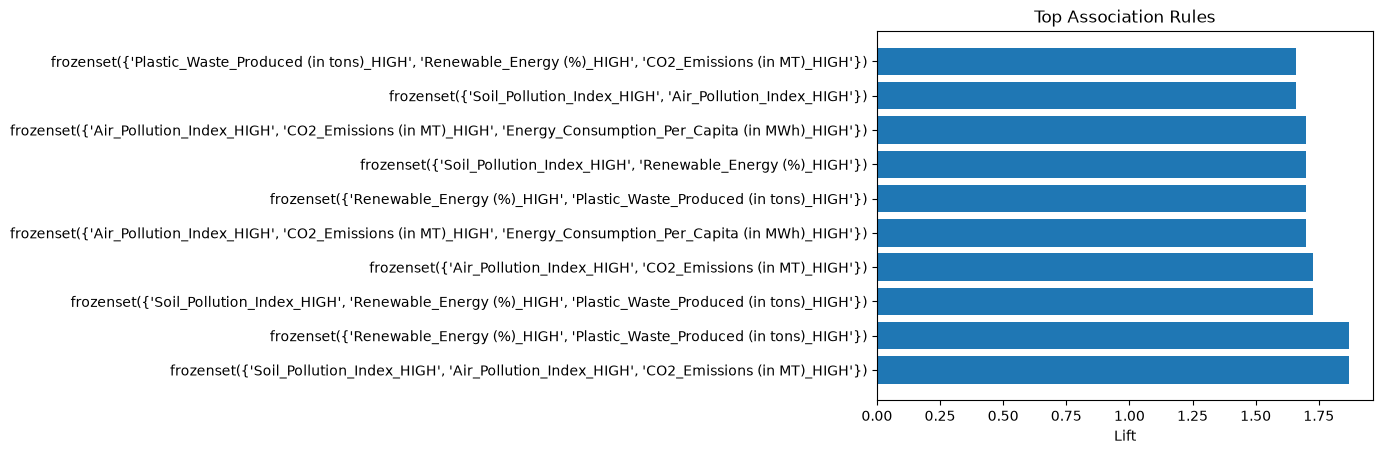

In [38]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure()
plt.barh(range(len(top_rules)), top_rules['lift'])
plt.yticks(range(len(top_rules)), top_rules['antecedents'].astype(str))
plt.xlabel("Lift")
plt.title("Top Association Rules")
plt.show()

# Final Insights & Outcomes

## 1) Data quality → modelling-ready
- **200 rows × 13 columns**, covering **20 years (2000–2019)**.
- **Zero** missing values, **zero** empty strings, **zero** duplicates — no imputation or cleaning was required before analysis.

## 2) EDA conclusions
- **Air pollution** is the most volatile index — repeated peaks (2003, 2006, 2009, 2012) and the **single highest peak in 2018**.
- **Industrial waste** consistently runs roughly **1.5–2× higher than plastic waste** across the whole period.
- **CO₂ emissions** stay in a **~18–34 MT** band with no sustained trend.
- All features are **weakly correlated with each other** (largest corr ≈ −0.16); energy recovered showed **no strong linear driver**.
- **Yearly pattern:** average pollution drifts upward while **energy recovered declines** — an inverse relationship worth investigating.
- **Top-10 most polluted countries** (by mean `Average_Pollution`): Saint Barthélemy, Bolivia, Central African Republic, Christmas Island, Papua New Guinea, Guinea-Bissau, Morocco, Philippines, Saint Lucia, Argentina → the natural **first-priority targets** for pollution-control, renewable-energy and waste-management programs.

## 3) Feature-engineering & modelling choices
- `StandardScaler` normalized the three indices; `LabelEncoder` encoded `Country`/`Year`; an `Average_Pollution` composite feature was engineered.
- The 8 continuous indicators were **binarized at (column mean)** into `HIGH/LOW`, giving a balanced transactional matrix (HIGH rates 48.5%–53.5%) — a simple and effective discretization for Apriori.

## 4) Apriori association-mining results
- At `min_support = 0.05` → **156 frequent itemsets** (8 singletons, 28 pairs, 56 triples, 68 quadruples, 4 quintuples).
- With `min lift > 1` → **852 association rules**; **lift range = 1.00 → 1.87** (moderate strength, no deterministic rule).
- **Strongest patterns (lift ≈ 1.66–1.87):**
  - `{Renewable energy HIGH, Plastic waste HIGH} ⇒ {Air HIGH, CO₂ HIGH, Soil HIGH}`
  - `{Air HIGH, CO₂ HIGH, Soil HIGH} ↔ {Renewable energy HIGH, Plastic waste HIGH}`
  - further clusters adding **`Energy consumption per capita HIGH`** with the air/CO₂/soil group (lift ≈ 1.70).

## 5) Outcomes & takeaways
1. **Pollution is a multi-factor phenomenon** — no single variable determines the others, so single-pronged policies (e.g. renewables alone) will not be enough.
2. **High renewable share co-exists with high air/soil/CO₂ pollution and high plastic waste** — adopting renewables is real, but it is not accompanied by low emissions on this dataset; consumption-driven waste is the separating factor.
3. The **reciprocal rule group** (Air∇CO₂∇Soil ↔ Renewable∇Plastic) defines a coherent *high-consuming, high-waste, still-highly-polluted* cluster of countries.
4. **Direct policy use-cases:** (a) prioritize the Top-10 polluted countries, (b) join **industrial/plastic-waste control** with **emissions & energy-consumption monitoring**, (c) use rule `confidence`/`lift` as a **screen for co-occurrence**, not as causation.
5. **Methodological caution:** mean-threshold binarization is arbitrary; re-running Apriori with **median/quantile cuts**, **higher min_support**, and stricter metrics (conviction/leverage/zhang) would harden these findings.


